# Tapering granularity: Scenario 2 with dipole trims

This follows Scenario 1, but the final horizontal-orbit correction uses one trim on the first bend of every three-dipole cell in the arc+DS regions.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xobjects as xo
import xtrack as xt
import re

In [2]:
line_path = "../acc-models-fcc-ee/lattices/t/fccee_t_merged_dipoles.json"

## Ideal Xsuite tapering

In [3]:
line = xt.load(line_path).fccee_p_ring
line.build_tracker(_context=xo.ContextCpu())
line.configure_radiation(model='mean')

Loading line from dict: 100%|██████████| 18995/18995 [00:02<00:00, 7333.19it/s]


In [4]:
line.compensate_radiation_energy_loss(delta0='zero_mean')

Compensating energy loss.
Share energy loss among cavities (repeat until energy loss is zero)
Energy loss: 8_148_214_673.634 eV             
Energy loss: 547_159_865.895 eV             
Energy loss: 39_263_508.462 eV             
Energy loss: 2_830_019.619 eV             
Energy loss: 204_045.916 eV             
Energy loss: 14_712.158 eV             
Energy loss: 1_060.780 eV             
Energy loss: 76.485 eV             
Energy loss: 5.516 eV             
Energy loss: 187_227_640.077 eV             
Energy loss: 30_859_907.299 eV             
Energy loss: -8_193_207.838 eV             
Energy loss: -3_540_866.802 eV             
Energy loss: -2_868.191 eV             
Energy loss: 250_680.922 eV             
Energy loss: 41_550.544 eV             
Energy loss: -10_927.730 eV             
Energy loss: -4_749.635 eV             
Energy loss: -8.289 eV             

  - Set delta_taper
  - Restore cavity voltage and frequency. Set cavity lag


In [5]:
elements_with_taper = np.asarray([ name for name in line.element_names if hasattr(line[name], "delta_taper")], dtype=str)
ideal_delta_taper = np.asarray([float(line[name].delta_taper) for name in elements_with_taper], dtype=float).copy()
ideal_taper_by_name = dict(zip(elements_with_taper, ideal_delta_taper))
twiss_ideal = line.twiss(eneloss_and_damping=True, radiation_analysis=True)
tt  = line.get_table()
print(f'Taperable elements: {len(ideal_delta_taper)}')
print(f'Ideal emittance: x={float(twiss_ideal.eq_gemitt_x)*1e9:.4g} nm, y={float(twiss_ideal.eq_gemitt_y)*1e12:.4g} pm')

/Users/skostogl/Documents/workspace/workspace_2025/python_installation/miniforge3/envs/FCC_xsuite/lib/python3.12/site-packages/xtrack/twiss.py:442: FutureWarning: The `eneloss_and_damping` keyword is deprecated and will be removed in future versions. 
Please use `radiation_analysis` instead, which has the same behavior. This deprecation is part of the interface cleanup in view of the 1.0 release.
  warn('The `eneloss_and_damping` keyword is deprecated and will be removed in future versions. \n'


Taperable elements: 15985
Ideal emittance: x=2.189 nm, y=0.06379 pm


In [6]:
def clear_delta_taper(line, elements_with_taper ):
    for name in elements_with_taper:
        line[name].delta_taper = 0.0

def restore_ideal_tapering(line,elements_with_taper, ideal_delta_taper):
    for name, value in zip(elements_with_taper, ideal_delta_taper):
        line[name].delta_taper = float(value)


def read_rf_phase(line):
    rows = []

    for name in line.element_names:
        element = line[name]

        if not hasattr(element, "voltage"):
            continue

        voltage = float(element.voltage)

        if voltage == 0:
            continue

        phase_taper = float(
            getattr(element, "phase_taper", 0.0)
        )

        rows.append({
            "name": name,
            "voltage_MV": voltage * 1e-6,
            "phase_taper_rad": phase_taper,
            "phase_taper_deg": np.rad2deg(phase_taper),
        })

    return pd.DataFrame(rows)

In [7]:
rf_phase_ideal = read_rf_phase(line)
rf_phase_ideal 

,name,voltage_MV,phase_taper_rad,phase_taper_deg
0,rf400.0,990.0,-1.103167,-63.206841
1,rf800.0,4020.0,-1.103153,-63.206005
2,rf800.1,4020.0,-1.103153,-63.206005
3,rf400.1,990.0,-1.103167,-63.206841


In [8]:
# i take this function from https://github.com/xsuite/xtrack/blob/main/xtrack/tapering.py

import numpy as np
from scipy.constants import c as clight

import xtrack as xt
import xobjects as xo

_print = print  # >>> CHANGED: replacement for `from .general import _print` in a notebook


def get_rf_phase(line, delta0='zero_mean', rtol_eneloss=1e-12,
                                      max_iter=100, verbose=True,
                                      co_search_at=None,
                                      **kwargs):

    assert isinstance(line._context, xo.ContextCpu), "Only CPU context is supported"
    assert line.particle_ref is not None, "Particle reference is not set"
    assert np.abs(line.particle_ref.q0) == 1, "Only |q0| = 1 is supported (for now)"

    enames_no_autodrift = [nn for nn in line.element_names if not nn.startswith('||drift_')]
    if len(set(enames_no_autodrift)) != len(enames_no_autodrift):
        raise ValueError("Line must not contain repeated elements to use "
                         "`solve_energy_profile_and_rf_phase(...)`. ")

    ele_type = line.tracker._tracker_data_base._line_table.element_type
    ele_type_set = set(ele_type)
    for et in ele_type_set:
        if 'SliceCavity' in et:
            raise ValueError(
                f"Element type '{et}' is not supported for radiation energy "
                "loss compensation.")

    if 'record_iterations' in kwargs:
        record_iterations = kwargs['record_iterations']
        kwargs.pop('record_iterations')
        line._tapering_iterations = []
    else:
        record_iterations = False

    if verbose: _print("Compensating energy loss.")

    line.config.XTRACK_MULTIPOLE_NO_SYNRAD = True
    with xt.line._preserve_track_flags(line):
        line.tracker.track_flags.XS_FLAG_KILL_CAVITY_KICK = True
        particle_on_co = line.find_closed_orbit(co_search_at=co_search_at,
                                                delta0=0 # 4d search
                                                )
    line.config.XTRACK_MULTIPOLE_NO_SYNRAD = False

    beta0 = float(particle_on_co._xobject.beta0[0])

    # >>> CHANGED: save the existing ideal or coarse magnet tapering
    delta_taper_setter = line.attr._cache['delta_taper'].multisetter
    delta_taper_before = delta_taper_setter.get_values().copy()

    # >>> CHANGED: the original "No compensation needed" early-return block
    # is removed so that the RF phase is always recomputed from scratch.

    # save voltages
    # Can do "own" as cavity slices are not supported here (see assert above)
    v_setter = line.attr._cache['_own_voltage'].multisetter
    f_setter = line.attr._cache['_own_frequency'].multisetter
    h_setter = line.attr._cache['_own_harmonic'].multisetter
    lag_setter = line.attr._cache['_own_lag'].multisetter
    phase_setter = line.attr._cache['_own_phase'].multisetter
    phase_taper_setter = line.attr._cache['_own_phase_taper'].multisetter

    v0 = v_setter.get_values()
    f0 = f_setter.get_values()
    h0 = h_setter.get_values()
    lag_zero = lag_setter.get_values()
    phase_zero = phase_setter.get_values()

    # Legacy, deprecated, clean up if used
    lag_taper_setter = line.attr._cache['_own_lag_taper'].multisetter
    lag_taper_setter.set_values(0 * phase_zero)

    f0_all = f0 + h0 / (line.tracker._tracker_data_base.line_length / beta0 / clight)
    eneloss_partitioning = v0 / v0.sum()

    # Put all cavities on crest and at zero frequency
    phase_taper_setter.set_values(np.pi/2 - np.deg2rad(lag_zero) - phase_zero)
    v_setter.set_values(np.zeros_like(v_setter.get_values()))
    f_setter.set_values(np.zeros_like(f_setter.get_values()))
    h_setter.set_values(np.zeros_like(h_setter.get_values()))

    if verbose: _print("Share energy loss among cavities (repeat until energy loss is zero)")
    with xt.line._preserve_track_flags(line):
        line.tracker.track_flags.XS_FLAG_SR_TAPER = True

        if delta0 == 'zero_mean':
            num_rounds = 2
            delta_start = 0
        else:
            num_rounds = 1
            delta_start = delta0

        for round in range(num_rounds):
            i_iter = 0

            while True:

                if round == 1 and delta0 == 'zero_mean':
                    delta_ave = xt.twiss.trapz(delta, ss) / ss[-1]
                    delta_start -= delta_ave

                p_test = particle_on_co.copy()
                p_test.delta = delta_start
                line.track(p_test, turn_by_turn_monitor='ONE_TURN_EBE')
                mon = line.record_last_track

                if record_iterations:
                    line._tapering_iterations.append(mon)

                eloss = -(mon.ptau[0, -1] - mon.ptau[0, 0]) * p_test.p0c[0]
                if verbose: _print(f"Energy loss: {eloss:_.3f} eV             ")

                if np.abs(eloss) < p_test.energy0[0] * rtol_eneloss:
                    break

                v_setter.set_values(v_setter.get_values()
                                    + eloss * eneloss_partitioning)

                delta = mon.delta[0, :-1]
                ss = mon.s[0, :-1]

                i_iter += 1
                if i_iter > max_iter:
                    raise RuntimeError("Maximum number of iterations reached")

    if verbose: _print()

    delta_taper_full = 0.5*(mon.delta[0, :-1] + mon.delta[0, 1:]) # last point is added by the monitor

    # >>> CHANGED: do not install ideal element-by-element magnet tapering
    #
    # Original Xsuite code removed:
    #
    # if verbose: _print("  - Set delta_taper")
    # delta_taper_mask = line.attr._cache['delta_taper'].mask
    # delta_taper_setter = line.attr._cache['delta_taper'].multisetter
    # delta_taper_setter.set_values(delta_taper_full[delta_taper_mask])

    if verbose: _print("  - Keep existing magnet tapering and set cavity lag")
    v_synchronous = v_setter.get_values()

    mask_cav = line.attr._cache['_own_voltage'].mask
    zeta_at_cav = np.atleast_1d(np.squeeze(mon.zeta[0, :-1]))[mask_cav]
    mask_active_cav = np.abs(v0) > 0
    v_ratio = v0 * 0
    v_ratio[mask_active_cav] = v_synchronous[mask_active_cav] / v0[mask_active_cav]
    assert np.all(np.abs(v_ratio[mask_active_cav]) < 1)
    inst_phase = np.arcsin(v_ratio)

    total_phase = (inst_phase - (2 * np.pi) * f0_all * zeta_at_cav / beta0 / clight)
    total_phase = np.pi - total_phase # we are above transition
    phase_taper = total_phase - np.deg2rad(lag_zero) - phase_zero
    phase_taper[~mask_active_cav] = 0

    v_setter.set_values(v0)
    f_setter.set_values(f0)
    h_setter.set_values(h0)
    lag_taper_setter.set_values(0 * phase_taper)
    phase_taper_setter.set_values(phase_taper)

    # >>> CHANGED: verify that ideal/coarse magnet settings were preserved
    delta_taper_after = delta_taper_setter.get_values()
    if not np.array_equal(delta_taper_before, delta_taper_after):
        raise RuntimeError("Magnet delta_taper settings changed during RF compensation")

    # >>> CHANGED: return the calculated energy profile and RF phase
    return {
        's': mon.s[0, :-1],
        'delta': delta_taper_full,
        'phase_taper': phase_taper,
        'energy_error_eV': float(eloss),
        'monitor': mon,
    }

In [9]:
clear_delta_taper(line, elements_with_taper)
get_rf_phase(line, delta0='zero_mean', rtol_eneloss=1e-12, max_iter=100, verbose=True, co_search_at=None)
rf_phase_no_tapering = read_rf_phase(line)

Compensating energy loss.
Share energy loss among cavities (repeat until energy loss is zero)
Energy loss: 8_148_214_673.634 eV             
Energy loss: 547_159_865.895 eV             
Energy loss: 39_263_508.462 eV             
Energy loss: 2_830_019.619 eV             
Energy loss: 204_045.916 eV             
Energy loss: 14_712.158 eV             
Energy loss: 1_060.780 eV             
Energy loss: 76.485 eV             
Energy loss: 5.516 eV             
Energy loss: 0.397 eV             
Energy loss: 0.028 eV             
Energy loss: 187_227_629.333 eV             
Energy loss: 30_859_910.916 eV             
Energy loss: -8_193_206.483 eV             
Energy loss: -3_540_866.837 eV             
Energy loss: -2_868.289 eV             
Energy loss: 250_680.909 eV             
Energy loss: 41_550.548 eV             
Energy loss: -10_927.728 eV             
Energy loss: -4_749.635 eV             
Energy loss: -8.289 eV             
Energy loss: 335.530 eV             
Energy loss: 5

In [10]:
rf_phase_ideal

,name,voltage_MV,phase_taper_rad,phase_taper_deg
0,rf400.0,990.0,-1.103167,-63.206841
1,rf800.0,4020.0,-1.103153,-63.206005
2,rf800.1,4020.0,-1.103153,-63.206005
3,rf400.1,990.0,-1.103167,-63.206841


In [11]:
rf_phase_no_tapering

,name,voltage_MV,phase_taper_rad,phase_taper_deg
0,rf400.0,990.0,-1.103168,-63.206845
1,rf800.0,4020.0,-1.103153,-63.206010
2,rf800.1,4020.0,-1.103153,-63.206010
3,rf400.1,990.0,-1.103168,-63.206845


/Users/skostogl/Documents/workspace/workspace_2025/python_installation/miniforge3/envs/FCC_xsuite/lib/python3.12/site-packages/xtrack/twiss.py:442: FutureWarning: The `eneloss_and_damping` keyword is deprecated and will be removed in future versions. 
Please use `radiation_analysis` instead, which has the same behavior. This deprecation is part of the interface cleanup in view of the 1.0 release.
  warn('The `eneloss_and_damping` keyword is deprecated and will be removed in future versions. \n'


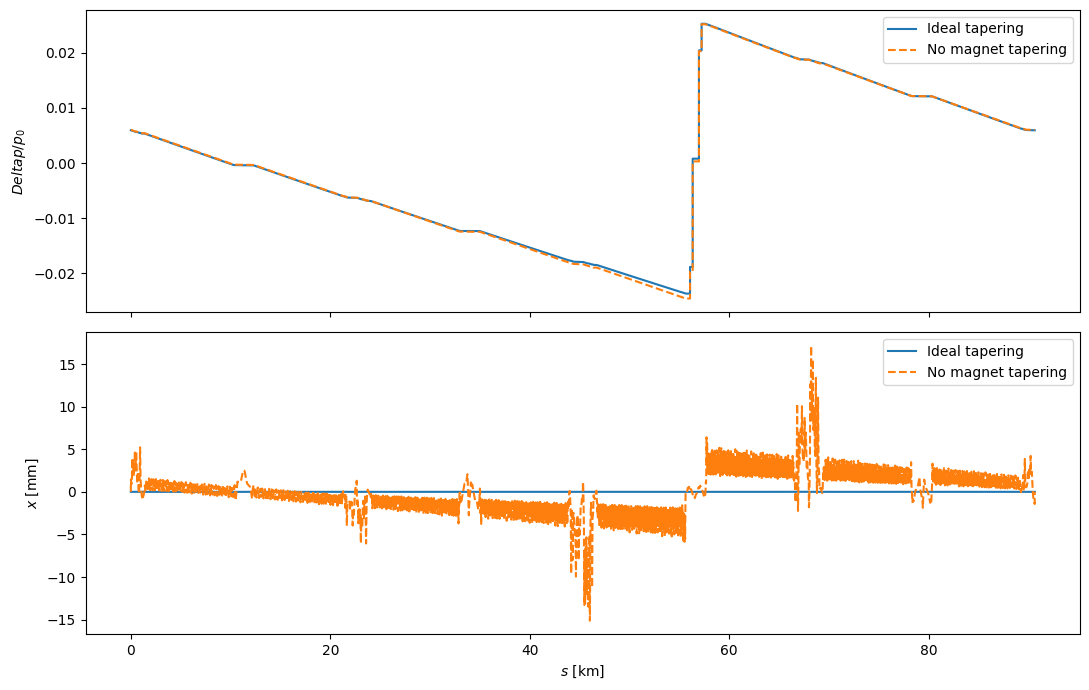

In [12]:
tw_no_taper = line.twiss(eneloss_and_damping=True)


fig, axes = plt.subplots(
    2,
    1,
    figsize=(11, 7),
    sharex=True,
)

axes[0].plot(
    twiss_ideal.s / 1e3,
    twiss_ideal.delta,
    color="tab:blue",
    lw=1.5,
    label="Ideal tapering",
)

axes[0].plot(
    tw_no_taper.s / 1e3,
    tw_no_taper.delta,
    color="tab:orange",
    ls="--",
    lw=1.5,
    label="No magnet tapering",
)

axes[0].set_ylabel(
    r"$Delta p/p_0$"
)

axes[0].legend()


axes[1].plot(
    twiss_ideal.s / 1e3,
    twiss_ideal.x * 1e3,
    color="tab:blue",
    lw=1.5,
    label="Ideal tapering",
)

axes[1].plot(
    tw_no_taper.s / 1e3,
    tw_no_taper.x * 1e3,
    color="tab:orange",
    ls="--",
    lw=1.5,
    label="No magnet tapering",
)

axes[1].set_xlabel(
    r"$s$ [km]"
)

axes[1].set_ylabel(
    r"$x$ [mm]"
)

axes[1].legend()

fig.tight_layout()
plt.show()




In [13]:
# use markers to split into regions
def split_lattice_regions(line):
    ips = ["ipa", "ipb", "ipd", "ipf", "ipg", "iph", "ipj", "ipl"]

    table = line.get_table()
    names = np.asarray(table.name, dtype=str)
    s = np.asarray(table.s, dtype=float)

    valid = names != "_end_point"
    names = names[valid]
    s = s[valid]

    s_by_name = dict(zip(names, s))

    def select(start_marker, end_marker):
        start = s_by_name[start_marker]
        end = s_by_name[end_marker]

        if start <= end:
            mask = (s >= start) & (s < end)
        else:
            mask = (s >= start) | (s < end)

        return names[mask]

    arcs = {}
    arc_ds = {}
    ds = {}
    insertions = {}

    for i, left_ip in enumerate(ips):
        right_ip = ips[(i + 1) % len(ips)]
        sector = f"{left_ip}_{right_ip}"

        arcs[sector] = select(
            f"end_ds_start_arc_{left_ip}",
            f"end_arc_start_ds_{right_ip}",
        )

        arc_ds[sector] = select(
            f"end_straight_start_ds_{left_ip}",
            f"end_ds_start_straight_{right_ip}",
        )

        right_ds = select(
            f"end_straight_start_ds_{left_ip}",
            f"end_ds_start_arc_{left_ip}",
        )

        left_ds = select(
            f"end_arc_start_ds_{right_ip}",
            f"end_ds_start_straight_{right_ip}",
        )

        ds[sector] = np.concatenate([right_ds, left_ds])

        insertions[right_ip] = select(
            f"end_ds_start_straight_{right_ip}",
            f"end_straight_start_ds_{right_ip}",
        )

    return {
        "arcs": arcs,
        "arc_ds": arc_ds,
        "ds": ds,
        "insertions": insertions,
    }

regions = split_lattice_regions(line)
regions


{'arcs': {'ipa_ipb': array(['bpm_qd1am.0', 'end_ds_start_arc_ipa', 'qd1am.0', ...,
         '||drift_30::323', 'bpm_qd1am.50', 'qd1am.50'],
        shape=(3053,), dtype='<U25'),
  'ipb_ipd': array(['end_ds_start_arc_ipb', 'qd1am.52', 'bpm_qd1am.52', ...,
         'mbd.1634', '||drift_36::287', 'qd1am.102'],
        shape=(3052,), dtype='<U25'),
  'ipd_ipf': array(['bpm_qd1am.104', 'end_ds_start_arc_ipd', 'qd1am.104', ...,
         '||drift_36::938', 'bpm_qd1am.154', 'qd1am.154'],
        shape=(3053,), dtype='<U25'),
  'ipf_ipg': array(['end_ds_start_arc_ipf', 'qd1am.156', 'bpm_qd1am.156', ...,
         'mbd.3314', '||drift_36::1473', 'qd1am.206'],
        shape=(3052,), dtype='<U25'),
  'ipg_iph': array(['bpm_qd1am.208', 'end_ds_start_arc_ipg', 'qd1am.208', ...,
         '||drift_36::2118', 'bpm_qd1am.258', 'qd1am.258'],
        shape=(3053,), dtype='<U25'),
  'iph_ipj': array(['end_ds_start_arc_iph', 'qd1am.260', 'bpm_qd1am.260', ...,
         'mbd.4934', '||drift_89::9', 'qd1am.310'

In [14]:
regions["insertions"]

{'ipb': array(['end_ds_start_straight_ipb', '||drift_30::350', 'bpm_qd6i',
        'hcor_qd6i', 'vcor_qd6i', 'qd6i', '||drift_39::0', 'bpm_qf7i',
        'hcor_qf7i', 'vcor_qf7i', 'qf7i', '||drift_39::1', 'bpm_qd8i',
        'hcor_qd8i', 'vcor_qd8i', 'qd8i', '||drift_39::2', 'bpm_qf9i',
        'hcor_qf9i', 'vcor_qf9i', 'qf9i', '||drift_40::0', 'di0l',
        '||drift_30::351', 'bpm_qd10i', 'hcor_qd10i', 'vcor_qd10i',
        'qd10i', '||drift_41::0', 'bpm_qf11i', 'hcor_qf11i', 'vcor_qf11i',
        'inj_kick1.0', 'qf11i', '||drift_30::352', 'mbd1_inj.0',
        'mbd1_inj.1', 'mbd1_inj.2', '||drift_42', 'mbd2_inj.0',
        'mbd2_inj.1', 'mbd2_inj.2', '||drift_30::353', 'bpm_qd12i',
        'hcor_qd12i', 'vcor_qd12i', 'qd12i', '||drift_43::0', 'bpm_qf13i',
        'hcor_qf13i', 'vcor_qf13i', 'inj_kick2.0', 'qf13i',
        '||drift_106::0', 'septum', '||drift_106::1', 'qf13j', 'bpm_qf13j',
        'hcor_qf13j', 'vcor_qf13j', 'inj_kick2.1', '||drift_43::1',
        'qd12j', 'bpm_qd12

# Step 1: set insertions to perfect tapering

In [15]:
clear_delta_taper(line, elements_with_taper)

# make it flat for all inserions
insertion_element_names_flat = np.concatenate(list(regions["insertions"].values()))

# filter only the elements that have tapering
insertion_mask = np.isin(elements_with_taper,insertion_element_names_flat)

insertion_elements_with_taper = elements_with_taper[insertion_mask]
insertion_ideal_delta_taper = ideal_delta_taper[insertion_mask]

restore_ideal_tapering(line, insertion_elements_with_taper, insertion_ideal_delta_taper)
get_rf_phase(line, delta0='zero_mean', rtol_eneloss=1e-12, max_iter=100, verbose=True, co_search_at=None)
rf_phase_insertions = read_rf_phase(line)

print(f"Restored ideal tapering for " f"{len(insertion_elements_with_taper)} insertion elements.")
rf_phase_insertions

Compensating energy loss.
Share energy loss among cavities (repeat until energy loss is zero)
Energy loss: 8_148_214_673.634 eV             
Energy loss: 547_159_865.895 eV             
Energy loss: 39_263_508.462 eV             
Energy loss: 2_830_019.619 eV             
Energy loss: 204_045.916 eV             
Energy loss: 14_712.158 eV             
Energy loss: 1_060.780 eV             
Energy loss: 76.485 eV             
Energy loss: 5.516 eV             
Energy loss: 0.397 eV             
Energy loss: 0.028 eV             
Energy loss: 187_227_629.333 eV             
Energy loss: 30_859_910.916 eV             
Energy loss: -8_193_206.483 eV             
Energy loss: -3_540_866.837 eV             
Energy loss: -2_868.289 eV             
Energy loss: 250_680.909 eV             
Energy loss: 41_550.548 eV             
Energy loss: -10_927.728 eV             
Energy loss: -4_749.635 eV             
Energy loss: -8.289 eV             
Energy loss: 335.530 eV             
Energy loss: 5

,name,voltage_MV,phase_taper_rad,phase_taper_deg
0,rf400.0,990.0,-1.103168,-63.206845
1,rf800.0,4020.0,-1.103153,-63.206010
2,rf800.1,4020.0,-1.103153,-63.206010
3,rf400.1,990.0,-1.103168,-63.206845


/Users/skostogl/Documents/workspace/workspace_2025/python_installation/miniforge3/envs/FCC_xsuite/lib/python3.12/site-packages/xtrack/twiss.py:442: FutureWarning: The `eneloss_and_damping` keyword is deprecated and will be removed in future versions. 
Please use `radiation_analysis` instead, which has the same behavior. This deprecation is part of the interface cleanup in view of the 1.0 release.
  warn('The `eneloss_and_damping` keyword is deprecated and will be removed in future versions. \n'


Text(0, 0.5, '$x$ [mm]')

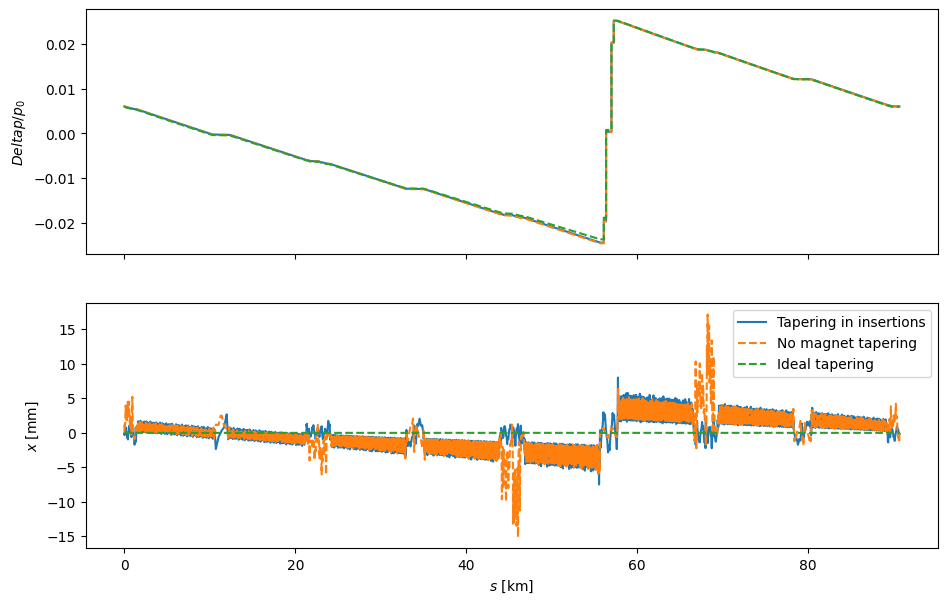

In [16]:
# twiss and plot orbit
twiss_insertion_taper = line.twiss(eneloss_and_damping=True)
fig, axes = plt.subplots(
    2,
    1,
    figsize=(11, 7),
    sharex=True,
)
plt.sca(axes[0])
plt.plot(
    twiss_insertion_taper.s / 1e3,
    twiss_insertion_taper.delta,
    color="tab:blue",
    lw=1.5,
    label="Tapering in insertions",
)
plt.plot(
    tw_no_taper.s / 1e3,
    tw_no_taper.delta,
    color="tab:orange",
    ls="--",
    lw=1.5,
    label="No magnet tapering",
)

plt.plot(
    
    twiss_ideal.s / 1e3,
    twiss_ideal.delta,
    color="tab:green",
    ls="--",
    lw=1.5,
    label="Ideal tapering",
)

plt.ylabel(r"$Delta p/p_0$")
plt.sca(axes[1])
plt.plot(
    twiss_insertion_taper.s / 1e3,
    twiss_insertion_taper.x * 1e3,
    color="tab:blue",
    lw=1.5,
    label="Tapering in insertions",
)
plt.plot(
    tw_no_taper.s / 1e3,
    tw_no_taper.x * 1e3,
    color="tab:orange",
    ls="--",
    lw=1.5,
    label="No magnet tapering",
)
plt.plot(
    twiss_ideal.s / 1e3,
    twiss_ideal.x * 1e3,
    color="tab:green",
    ls="--",
    lw=1.5,
    label="Ideal tapering",
)

plt.legend()
plt.xlabel(r"$s$ [km]")
plt.ylabel(r"$x$ [mm]")

# Define circuits

In [17]:
import re
import numpy as np
import pandas as pd


def define_arc_circuits(line, regions):
    table = line.get_table()

    type_by_name = dict(
        zip(
            np.asarray(table.name, dtype=str),
            np.asarray(table.element_type, dtype=str),
        )
    )

    taperable = {
        name
        for name in line.element_names
        if hasattr(line[name], "delta_taper")
    }

    def family(name):
        # qf2a.15 -> qf2a
        # sf1a.32 -> sf1a
        return re.sub(r"\.\d+$", "", name.lower())

    def select(elements, element_type=None, prefix=None):
        selected = []

        for name in elements:
            if name not in taperable:
                continue

            if element_type is not None:
                if element_type not in type_by_name.get(name, ""):
                    continue

            if prefix is not None:
                prefixes = (
                    (prefix,)
                    if isinstance(prefix, str)
                    else tuple(prefix)
                )

                if not family(name).startswith(prefixes):
                    continue

            selected.append(name)

        return np.asarray(selected, dtype=str)

    def split_in_two(elements):
        """
        Split an ordered family into two contiguous circuits.

        The first circuit contains the first half of the magnets along s.
        The second circuit contains the remaining magnets.
        """
        elements = np.asarray(elements, dtype=str)

        first, second = np.array_split(elements, 2)

        return first, second

    circuits = {}

    for sector in regions["arcs"]:

        arc_elements = regions["arcs"][sector]
        arc_ds_elements = regions["arc_ds"][sector]

        # One dipole circuit for the full DS-arc-DS sector.
        circuits[f"DIP_{sector}"] = select(
            arc_ds_elements,
            element_type="Bend",
        )

        # --------------------------------------------------------------
        # Quadrupoles
        #
        # Original circuits:
        #   QF, QD
        #
        # New circuits:
        #   QF_1, QF_2, QD_1, QD_2
        # --------------------------------------------------------------

        qf_elements = select(
            arc_ds_elements,
            element_type="Quadrupole",
            prefix="qf",
        )

        qd_elements = select(
            arc_ds_elements,
            element_type="Quadrupole",
            prefix="qd",
        )

        qf_1, qf_2 = split_in_two(qf_elements)
        qd_1, qd_2 = split_in_two(qd_elements)

        circuits[f"QF_1_{sector}"] = qf_1
        circuits[f"QF_2_{sector}"] = qf_2
        circuits[f"QD_1_{sector}"] = qd_1
        circuits[f"QD_2_{sector}"] = qd_2

        # --------------------------------------------------------------
        # Sextupoles
        #
        # Original circuits:
        #   SF1, SF2, SD1, SD2
        #
        # Each family is now divided longitudinally into two circuits,
        # giving eight sextupole circuits per arc.
        # --------------------------------------------------------------

        sextupole_families = {
            "SF1": "sf1a",
            "SF2": "sf2a",
            "SD1": "sd1a",
            "SD2": "sd2a",
        }

        for circuit_family, prefix in sextupole_families.items():

            family_elements = select(
                arc_elements,
                element_type="Sextupole",
                prefix=prefix,
            )

            first, second = split_in_two(family_elements)

            circuits[f"{circuit_family}_1_{sector}"] = first
            circuits[f"{circuit_family}_2_{sector}"] = second

    # Remove empty circuits.
    circuits = {
        name: elements
        for name, elements in circuits.items()
        if len(elements) > 0
    }

    return circuits

In [18]:
circuits = define_arc_circuits(line, regions)

summary = pd.DataFrame([
    {
        "circuit": circuit,
        "number_of_elements": len(elements),
        "first_element": elements[0],
        "last_element": elements[-1],
    }
    for circuit, elements in circuits.items()
])

display(summary)

,circuit,number_of_elements,first_element,last_element
0,DIP_ipa_ipb,840,mbd.0,mbd.839
1,QF_1_ipa_ipb,71,qf5m.0,qf3a.13
2,QF_2_ipa_ipb,70,qf2a.53,qf5i
3,QD_1_ipa_ipb,71,qd6m.0,qd1a.53
4,QD_2_ipa_ipb,70,qd1a.54,qd4i
...,...,...,...,...
99,SF2_2_ipl_ipa,25,sf2a.383,sf2a.407
100,SD1_1_ipl_ipa,25,sd1a.358,sd1a.382
101,SD1_2_ipl_ipa,25,sd1a.383,sd1a.407
102,SD2_1_ipl_ipa,25,sd2a.358,sd2a.382


# Step 2: set dipoles in coarse granularity

In [19]:
def apply_average_circuit_tapering(
    line,
    circuits,
    ideal_taper_by_name,
    circuit_prefixes,
):
    settings = []

    for circuit_name, circuit_elements in circuits.items():

        if not circuit_name.startswith(tuple(circuit_prefixes)):
            continue

        elements = [
            name for name in circuit_elements
            if name in ideal_taper_by_name
        ]

        if len(elements) == 0:
            continue

        ideal_values = np.asarray(
            [ideal_taper_by_name[name] for name in elements],
            dtype=float,
        )

        # I use average
        circuit_value = np.mean(ideal_values)

        for name in elements:
            line[name].delta_taper = float(circuit_value)

        settings.append({
            "circuit": circuit_name,
            "number_of_elements": len(elements),
            "applied_delta_taper": circuit_value,
            "ideal_min": np.min(ideal_values),
            "ideal_max": np.max(ideal_values),
            "maximum_error": np.max(
                np.abs(ideal_values - circuit_value)
            ),
        })

    return pd.DataFrame(settings)

In [20]:
flag_dipoles_coarse = True

if flag_dipoles_coarse:
    dipole_circuit_settings = apply_average_circuit_tapering(
        line,
        circuits,
        ideal_taper_by_name,
        circuit_prefixes=("DIP",),
    )

    display(dipole_circuit_settings)
else:
        
    dipole_element_names_flat = np.concatenate([
        elements
        for circuit_name, elements in circuits.items()
        if circuit_name.startswith("DIP")
    ])

    dipole_mask = np.isin(
        elements_with_taper,
        dipole_element_names_flat,
    )

    dipole_elements_with_taper = elements_with_taper[
        dipole_mask
    ]

    dipole_ideal_delta_taper = ideal_delta_taper[
        dipole_mask
    ]

    restore_ideal_tapering(
        line,
        dipole_elements_with_taper,
        dipole_ideal_delta_taper,
    )

    print(
        "Restored ideal tapering for "
        f"{len(dipole_elements_with_taper)} DS–arc–DS dipoles."
    )

,circuit,number_of_elements,applied_delta_taper,ideal_min,ideal_max,maximum_error
0,DIP_ipa_ipb,840,0.002485,-0.000367,0.005360,0.002874
1,DIP_ipb_ipd,840,-0.003249,-0.006037,-0.000440,0.002809
2,DIP_ipd_ipf,840,-0.009617,-0.012334,-0.006879,0.002738
3,DIP_ipf_ipg,840,-0.015039,-0.017698,-0.012361,0.002678
4,DIP_ipg_iph,840,-0.021113,-0.023708,-0.018501,0.002612
5,DIP_iph_ipj,840,0.022189,0.019107,0.025289,0.003100
6,DIP_ipj_ipl,840,0.015154,0.012155,0.018177,0.003023
7,DIP_ipl_ipa,840,0.009173,0.006244,0.012125,0.002952


Compensating energy loss.
Share energy loss among cavities (repeat until energy loss is zero)
Energy loss: 8_148_214_673.634 eV             
Energy loss: 547_159_865.895 eV             
Energy loss: 39_263_508.462 eV             
Energy loss: 2_830_019.619 eV             
Energy loss: 204_045.916 eV             
Energy loss: 14_712.158 eV             
Energy loss: 1_060.780 eV             
Energy loss: 76.485 eV             
Energy loss: 5.516 eV             
Energy loss: 0.397 eV             
Energy loss: 0.028 eV             
Energy loss: 187_227_629.333 eV             
Energy loss: 30_859_910.916 eV             
Energy loss: -8_193_206.483 eV             
Energy loss: -3_540_866.837 eV             
Energy loss: -2_868.289 eV             
Energy loss: 250_680.909 eV             
Energy loss: 41_550.548 eV             
Energy loss: -10_927.728 eV             
Energy loss: -4_749.635 eV             
Energy loss: -8.289 eV             
Energy loss: 335.530 eV             
Energy loss: 5

/Users/skostogl/Documents/workspace/workspace_2025/python_installation/miniforge3/envs/FCC_xsuite/lib/python3.12/site-packages/xtrack/twiss.py:442: FutureWarning: The `eneloss_and_damping` keyword is deprecated and will be removed in future versions. 
Please use `radiation_analysis` instead, which has the same behavior. This deprecation is part of the interface cleanup in view of the 1.0 release.
  warn('The `eneloss_and_damping` keyword is deprecated and will be removed in future versions. \n'


Text(0, 0.5, '$x$ [mm]')

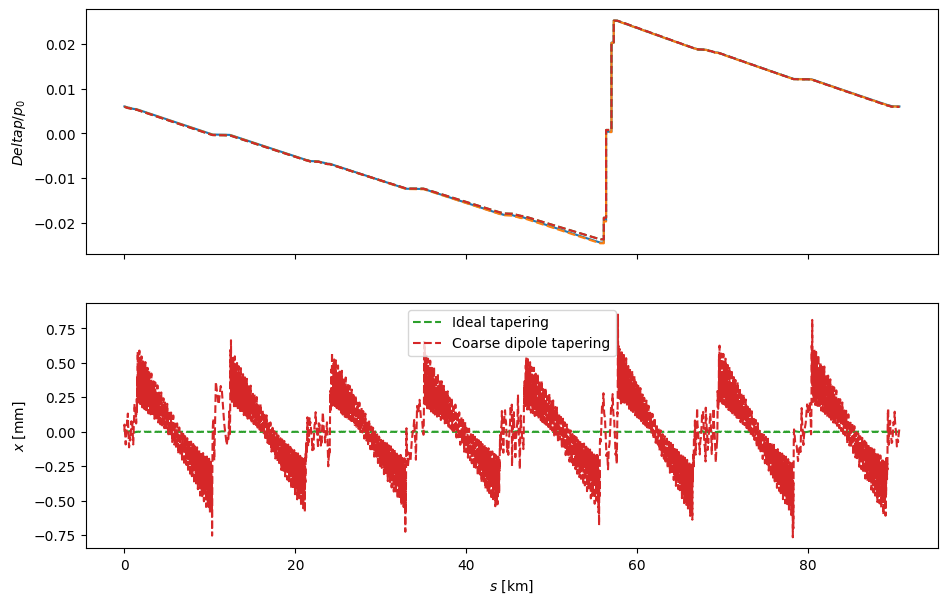

In [21]:
# Recompute the RF phase after changing the dipole tapering.
get_rf_phase(line, delta0='zero_mean', rtol_eneloss=1e-12, max_iter=100, verbose=True, co_search_at=None)
rf_phase_dipole = read_rf_phase(line)

# Twiss and plot orbit
twiss_dipole = line.twiss(eneloss_and_damping=True)
fig, axes = plt.subplots(
    2,
    1,
    figsize=(11, 7),
    sharex=True,
)
plt.sca(axes[0])
plt.plot(
    twiss_insertion_taper.s / 1e3,
    twiss_insertion_taper.delta,
    color="tab:blue",
    lw=1.5,
    label="Tapering in insertions",
)
plt.plot(
    tw_no_taper.s / 1e3,
    tw_no_taper.delta,
    color="tab:orange",
    ls="--",
    lw=1.5,
    label="No magnet tapering",
)

plt.plot(
    
    twiss_ideal.s / 1e3,
    twiss_ideal.delta,
    color="tab:green",
    ls="--",
    lw=1.5,
    label="Ideal tapering",
)

plt.plot(
    twiss_dipole.s / 1e3,
    twiss_dipole.delta,
    color="tab:red",
    ls="--",
    lw=1.5,
    label="Coarse dipole tapering",
)

plt.ylabel(r"$Delta p/p_0$")
plt.sca(axes[1])
#plt.plot(
#    twiss_insertion_taper.s / 1e3,
#    twiss_insertion_taper.x * 1e3,
#    color="tab:blue",
#    lw=1.5,
#    label="Tapering in insertions",
#)
#plt.plot(
#    tw_no_taper.s / 1e3,
#    tw_no_taper.x * 1e3,
#    color="tab:orange",
#    ls="--",
#    lw=1.5,
#    label="No magnet tapering",
#)
plt.plot(
    twiss_ideal.s / 1e3,
    twiss_ideal.x * 1e3,
    color="tab:green",
    ls="--",
    lw=1.5,
    label="Ideal tapering",
)

plt.plot(
    twiss_dipole.s / 1e3,
    twiss_dipole.x * 1e3,
    color="tab:red",
    ls="--",
    lw=1.5,
    label="Coarse dipole tapering",
)

plt.legend()
plt.xlabel(r"$s$ [km]")
plt.ylabel(r"$x$ [mm]")

# Step 3 set quad and sextupoles in coarse granularity

In [22]:
# Step 2a: quadrupole tapering with circuit granularity

flag_quad_coarse = True

if flag_quad_coarse:
    quadrupole_circuit_settings = apply_average_circuit_tapering(
        line,
        circuits,
        ideal_taper_by_name,
        circuit_prefixes=("QF", "QD"),
    )

    display(quadrupole_circuit_settings)


else:
    # Step 2a: ideal element-by-element quadrupole tapering

    quadrupole_element_names_flat = np.concatenate([
        elements
        for circuit_name, elements in circuits.items()
        if circuit_name.startswith(("QF", "QD"))
    ])

    quadrupole_mask = np.isin(
        elements_with_taper,
        quadrupole_element_names_flat,
    )

    quadrupole_elements_with_taper = elements_with_taper[
        quadrupole_mask
    ]

    quadrupole_ideal_delta_taper = ideal_delta_taper[
        quadrupole_mask
    ]

    restore_ideal_tapering(
        line,
        quadrupole_elements_with_taper,
        quadrupole_ideal_delta_taper,
    )

    print(
        "Restored ideal tapering for "
        f"{len(quadrupole_elements_with_taper)} quadrupoles."
    )

,circuit,number_of_elements,applied_delta_taper,ideal_min,ideal_max,maximum_error
0,QF_1_ipa_ipb,71,0.003918,0.002480,0.005336,0.001438
1,QF_2_ipa_ipb,70,0.001032,-0.000357,0.002439,0.001407
2,QD_1_ipa_ipb,71,0.003939,0.002500,0.005349,0.001438
3,QD_2_ipa_ipb,70,0.001052,-0.000344,0.002459,0.001407
4,QF_1_ipb_ipd,71,-0.001848,-0.003254,-0.000450,0.001406
5,QF_2_ipb_ipd,70,-0.004669,-0.006014,-0.003294,0.001375
6,QD_1_ipb_ipd,71,-0.001868,-0.003274,-0.000463,0.001406
7,QD_2_ipb_ipd,70,-0.004689,-0.006027,-0.003314,0.001375
8,QF_1_ipd_ipf,71,-0.008252,-0.009622,-0.006902,0.001370
9,QF_2_ipd_ipf,70,-0.011001,-0.012325,-0.009661,0.001341


In [23]:
flag_sext_coarse = True

if flag_sext_coarse:
    sextupole_circuit_settings = apply_average_circuit_tapering(
        line,
        circuits,
        ideal_taper_by_name,
        circuit_prefixes=("SF", "SD"),
    )

    display(sextupole_circuit_settings)

else:
    # Step 2b: ideal element-by-element sextupole tapering

    sextupole_element_names_flat = np.concatenate([
        elements
        for circuit_name, elements in circuits.items()
        if circuit_name.startswith(("SF", "SD"))
    ])

    sextupole_mask = np.isin(
        elements_with_taper,
        sextupole_element_names_flat,
    )

    sextupole_elements_with_taper = elements_with_taper[
        sextupole_mask
    ]

    sextupole_ideal_delta_taper = ideal_delta_taper[
        sextupole_mask
    ]

    restore_ideal_tapering(
        line,
        sextupole_elements_with_taper,
        sextupole_ideal_delta_taper,
    )

    print(
        "Restored ideal tapering for "
        f"{len(sextupole_elements_with_taper)} sextupoles."
    )

,circuit,number_of_elements,applied_delta_taper,ideal_min,ideal_max,maximum_error
0,SF1_1_ipa_ipb,25,0.003764,0.002521,0.004991,0.001243
1,SF1_2_ipa_ipb,25,0.001205,-0.000006,0.002439,0.001234
2,SF2_1_ipa_ipb,25,0.003765,0.002562,0.005032,0.001267
3,SF2_2_ipa_ipb,25,0.001203,-0.000046,0.002398,0.001250
4,SD1_1_ipa_ipb,25,0.003765,0.002541,0.005011,0.001247
...,...,...,...,...,...,...
59,SF2_2_ipl_ipa,25,0.007857,0.006573,0.009084,0.001283
60,SD1_1_ipl_ipa,25,0.010487,0.009231,0.011768,0.001281
61,SD1_2_ipl_ipa,25,0.007857,0.006594,0.009105,0.001263
62,SD2_1_ipl_ipa,25,0.010485,0.009189,0.011725,0.001297


In [24]:
get_rf_phase(line, delta0='zero_mean', rtol_eneloss=1e-12, max_iter=100, verbose=True, co_search_at=None)
rf_phase_quad_sext = read_rf_phase(line)

rf_phase_quad_sext

Compensating energy loss.
Share energy loss among cavities (repeat until energy loss is zero)
Energy loss: 8_148_214_673.634 eV             
Energy loss: 547_159_865.895 eV             
Energy loss: 39_263_508.462 eV             
Energy loss: 2_830_019.619 eV             
Energy loss: 204_045.916 eV             
Energy loss: 14_712.158 eV             
Energy loss: 1_060.780 eV             
Energy loss: 76.485 eV             
Energy loss: 5.516 eV             
Energy loss: 0.397 eV             
Energy loss: 0.028 eV             
Energy loss: 187_227_629.333 eV             
Energy loss: 30_859_910.916 eV             
Energy loss: -8_193_206.483 eV             
Energy loss: -3_540_866.837 eV             
Energy loss: -2_868.289 eV             
Energy loss: 250_680.909 eV             
Energy loss: 41_550.548 eV             
Energy loss: -10_927.728 eV             
Energy loss: -4_749.635 eV             
Energy loss: -8.289 eV             
Energy loss: 335.530 eV             
Energy loss: 5

,name,voltage_MV,phase_taper_rad,phase_taper_deg
0,rf400.0,990.0,-1.103168,-63.206845
1,rf800.0,4020.0,-1.103153,-63.206010
2,rf800.1,4020.0,-1.103153,-63.206010
3,rf400.1,990.0,-1.103168,-63.206845


/Users/skostogl/Documents/workspace/workspace_2025/python_installation/miniforge3/envs/FCC_xsuite/lib/python3.12/site-packages/xtrack/twiss.py:442: FutureWarning: The `eneloss_and_damping` keyword is deprecated and will be removed in future versions. 
Please use `radiation_analysis` instead, which has the same behavior. This deprecation is part of the interface cleanup in view of the 1.0 release.
  warn('The `eneloss_and_damping` keyword is deprecated and will be removed in future versions. \n'


Text(0, 0.5, '$x$ [mm]')

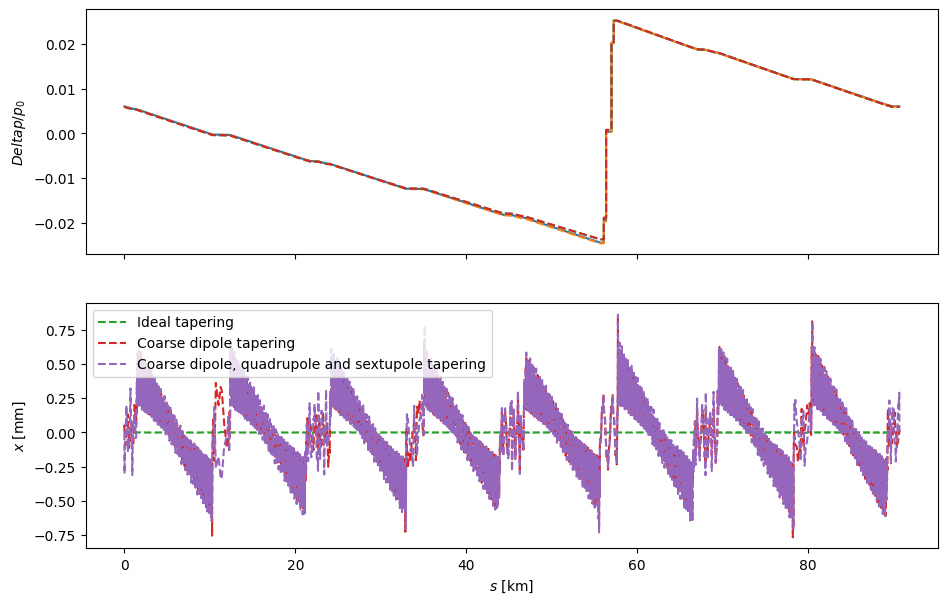

In [25]:
# twiss and plot orbit
twiss_quad_sext = line.twiss(eneloss_and_damping=True, radiation_analysis=True)
fig, axes = plt.subplots(
    2,
    1,
    figsize=(11, 7),
    sharex=True,
)
plt.sca(axes[0])
plt.plot(
    twiss_insertion_taper.s / 1e3,
    twiss_insertion_taper.delta,
    color="tab:blue",
    lw=1.5,
    label="Tapering in insertions",
)
plt.plot(
    tw_no_taper.s / 1e3,
    tw_no_taper.delta,
    color="tab:orange",
    ls="--",
    lw=1.5,
    label="No magnet tapering",
)

plt.plot(
    
    twiss_ideal.s / 1e3,
    twiss_ideal.delta,
    color="tab:green",
    ls="--",
    lw=1.5,
    label="Ideal tapering",
)

plt.plot(
    twiss_quad_sext.s / 1e3,
    twiss_quad_sext.delta,
    color="tab:red",
    ls="--",
    lw=1.5,
    label="Coarse quadrupole and sextupole tapering",
)

plt.ylabel(r"$Delta p/p_0$")
plt.sca(axes[1])

plt.plot(
    twiss_ideal.s / 1e3,
    twiss_ideal.x * 1e3,
    color="tab:green",
    ls="--",
    lw=1.5,
    label="Ideal tapering",
)

# dipoles
plt.plot(
    twiss_dipole.s / 1e3,
    twiss_dipole.x * 1e3,
    color="tab:red",
    ls="--",
    lw=1.5,
    label="Coarse dipole tapering",
)

plt.plot(
    twiss_quad_sext.s / 1e3,
    twiss_quad_sext.x * 1e3,
    color="tab:purple",
    ls="--",
    lw=1.5,
    label="Coarse dipole, quadrupole and sextupole tapering",
)

plt.legend()
plt.xlabel(r"$s$ [km]")
plt.ylabel(r"$x$ [mm]")

# Step 4: correct the horizontal orbit with one dipole trim per arc+DS cell

In [52]:
twiss_ideal["length"]

array([0. , 0. , 2.4, ..., 2.4, 0. , 0. ], shape=(30053,))

In [53]:
from scipy.sparse.linalg import lsmr


def dipoles_in_region(line, element_names):
    # first step isolate the dipoles in each arc
    table = line.get_table()
    type_by_name = dict(zip(np.asarray(table.name, dtype=str),np.asarray(table.element_type, dtype=str)))

    return np.asarray([
        str(name) for name in element_names
        if "Bend" in type_by_name.get(str(name), "")
    ], dtype=str)


def select_first_dipole_of_each_cell(line, regions):
    table = line.get_table()
    tw = line.twiss(eneloss_and_damping=True)
    s_by_name = dict(zip(
        np.asarray(table.name, dtype=str),
        np.asarray(table.s, dtype=float),
    ))
    length_by_name = dict(zip(
        np.asarray(tw.name, dtype=str),
        np.asarray(tw.length, dtype=float),
    ))

    selected = []
    rows = []
    # i keep dipoles also in the DS
    for sector, arc_ds_elements in regions["arc_ds"].items():
        dipoles = dipoles_in_region(line, arc_ds_elements)

        if len(dipoles) % 3 != 0:
            raise ValueError(
                f"{sector} contains {len(dipoles)} dipoles; "
                "the number is not divisible by three."
            )

        dipole_triplets = dipoles.reshape(-1, 3)

        for cell_number, triplet in enumerate(dipole_triplets):
            trim_dipole = str(triplet[0])
            selected.append(trim_dipole)
            rows.append({
                "sector": sector,
                "cell": cell_number,
                "trim_dipole": trim_dipole,
                "second_dipole": str(triplet[1]),
                "third_dipole": str(triplet[2]),
                "s_km": s_by_name[trim_dipole] / 1e3,
                "length_m": length_by_name[trim_dipole]
            })

    return np.asarray(selected, dtype=str), pd.DataFrame(rows)


def validate_first_dipole_selection(line, regions, trim_dipole_names, trim_layout):
    expected = []
    sector_rows = []

    for sector, arc_ds_elements in regions["arc_ds"].items():
        dipoles = dipoles_in_region(line, arc_ds_elements)
        assert len(dipoles) % 3 == 0

        expected_sector = dipoles[::3]
        expected.extend(expected_sector)

        selected_sector = trim_layout.loc[
            trim_layout["sector"] == sector,
            "trim_dipole",
        ].to_numpy(dtype=str)

        sector_rows.append({
            "sector": sector,
            "dipoles_in_arc_ds": len(dipoles),
            "expected_trims": len(expected_sector),
            "selected_trims": len(selected_sector),
            "selection_is_correct": np.array_equal(
                selected_sector,
                expected_sector,
            ),
        })

    expected = np.asarray(expected, dtype=str)
    selected = np.asarray(trim_dipole_names, dtype=str)

    assert len(selected) == len(np.unique(selected)), "Duplicate trim dipoles found"
    assert np.array_equal(selected, expected), (
        "The selected list is not exactly every third dipole, beginning "
        "with the first dipole, in each arc+DS sector."
    )
    assert np.all(
        trim_layout["trim_dipole"].to_numpy(dtype=str)
        != trim_layout["second_dipole"].to_numpy(dtype=str)
    )
    assert np.all(
        trim_layout["trim_dipole"].to_numpy(dtype=str)
        != trim_layout["third_dipole"].to_numpy(dtype=str)
    )

    summary = pd.DataFrame(sector_rows)
    assert summary["selection_is_correct"].all()

    print(
        f"Validated {len(selected)} trims: exactly the first dipole of "
        f"{len(selected)} three-dipole cells in the arc+DS regions."
    )
    return summary


def set_horizontal_dipole_trim_kicks(
    line,
    dipole_names,
    base_knl,
    trim_kicks_rad,
):
    for dipole_name, base_value, kick in zip(
        dipole_names,
        base_knl,
        trim_kicks_rad,
    ):
        # A positive horizontal kick corresponds to a negative knl[0].
        line.element_refs[dipole_name].knl[0] = float(base_value - kick)


def prepare_horizontal_dipole_trims(line, dipole_names):
    base_knl = np.asarray([
        float(line[name].knl[0]) for name in dipole_names
    ], dtype=float)

    set_horizontal_dipole_trim_kicks(
        line,
        dipole_names,
        base_knl,
        np.zeros(len(dipole_names)),
    )
    return base_knl


def verify_horizontal_dipole_trims(
    line,
    dipole_names,
    base_knl,
    test_kick_rad=1e-9,
):
    test_kicks = np.full(len(dipole_names), test_kick_rad)
    set_horizontal_dipole_trim_kicks(
        line,
        dipole_names,
        base_knl,
        test_kicks,
    )

    installed_knl = np.asarray([
        float(line[name].knl[0]) for name in dipole_names
    ])
    expected_knl = base_knl - test_kicks

    # Restore zero trims before starting the correction.
    set_horizontal_dipole_trim_kicks(
        line,
        dipole_names,
        base_knl,
        np.zeros(len(dipole_names)),
    )

    if not np.allclose(installed_knl, expected_knl, rtol=1e-10, atol=1e-16):
        bad = np.flatnonzero(~np.isclose(
            installed_knl,
            expected_knl,
            rtol=1e-10,
            atol=1e-16,
        ))
        raise RuntimeError(
            f"{len(bad)} numerical dipole trims failed the knl[0] test. "
            f"First failed element: {dipole_names[bad[0]]}"
        )

    print(
        f"Verified {len(dipole_names)} numerical trims in knl[0]."
    )

In [54]:
# BPMs and one selected dipole trim per three-dipole cell in arc+DS.
tt_monitors = tt.rows['bpm.*']
monitor_names = np.asarray(tt_monitors.name, dtype=str)
monitor_s = np.asarray(tt_monitors.s, dtype=float)

In [55]:
trim_dipole_names, trim_layout = select_first_dipole_of_each_cell(
    line,
    regions,
)

selection_summary = validate_first_dipole_selection(
    line,
    regions,
    trim_dipole_names,
    trim_layout,
)

/Users/skostogl/Documents/workspace/workspace_2025/python_installation/miniforge3/envs/FCC_xsuite/lib/python3.12/site-packages/xtrack/twiss.py:442: FutureWarning: The `eneloss_and_damping` keyword is deprecated and will be removed in future versions. 
Please use `radiation_analysis` instead, which has the same behavior. This deprecation is part of the interface cleanup in view of the 1.0 release.
  warn('The `eneloss_and_damping` keyword is deprecated and will be removed in future versions. \n'


Validated 2240 trims: exactly the first dipole of 2240 three-dipole cells in the arc+DS regions.


In [29]:
trim_base_knl = prepare_horizontal_dipole_trims(
    line,
    trim_dipole_names,
)
verify_horizontal_dipole_trims(
    line,
    trim_dipole_names,
    trim_base_knl,
)


Verified 2240 numerical trims in knl[0].


BPMs: 2636
Horizontal dipole trims: 2240


,sector,dipoles_in_arc_ds,expected_trims,selected_trims,selection_is_correct
0,ipa_ipb,840,280,280,True
1,ipb_ipd,840,280,280,True
2,ipd_ipf,840,280,280,True
3,ipf_ipg,840,280,280,True
4,ipg_iph,840,280,280,True
5,iph_ipj,840,280,280,True
6,ipj_ipl,840,280,280,True
7,ipl_ipa,840,280,280,True


,sector,cell,trim_dipole,second_dipole,third_dipole,s_km
0,ipa_ipb,0,mbd.0,mbd.1,mbd.2,1.363667
1,ipa_ipb,1,mbd.3,mbd.4,mbd.5,1.394737
2,ipa_ipb,2,mbd.6,mbd.7,mbd.8,1.428962
3,ipa_ipb,3,mbd.9,mbd.10,mbd.11,1.461062
4,ipa_ipb,4,mbd.12,mbd.13,mbd.14,1.495687
5,ipa_ipb,5,mbd.15,mbd.16,mbd.17,1.526757
6,ipa_ipb,6,mbd.18,mbd.19,mbd.20,1.559257
7,ipa_ipb,7,mbd.21,mbd.22,mbd.23,1.590947
8,ipa_ipb,8,mbd.24,mbd.25,mbd.26,1.623447
9,ipa_ipb,9,mbd.27,mbd.28,mbd.29,1.655137


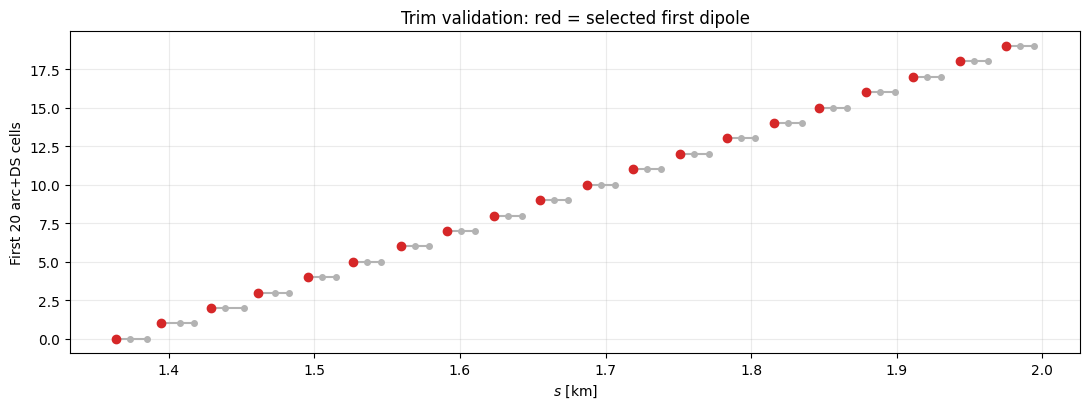

In [32]:





print(f"BPMs: {len(monitor_names)}")
print(f"Horizontal dipole trims: {len(trim_dipole_names)}")
display(selection_summary)
display(trim_layout.head(12))

# Visual check: within every row, the red point must be the first of the
# three ordered dipoles shown in grey.
check_rows = trim_layout.iloc[:20]
fig, ax = plt.subplots(figsize=(11, 4.2))
for row_number, row in enumerate(check_rows.itertuples(index=False)):
    names = [row.trim_dipole, row.second_dipole, row.third_dipole]
    table_indices = tt.rows.indices[names]
    s_triplet = np.asarray(tt.s[table_indices], dtype=float) / 1e3
    ax.plot(s_triplet, np.full(3, row_number), 'o-', color='0.7', ms=4)
    ax.plot(s_triplet[0], row_number, 'o', color='tab:red', ms=6)

ax.set_xlabel(r'$s$ [km]')
ax.set_ylabel('First 20 arc+DS cells')
ax.set_title('Trim validation: red = selected first dipole')
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

In [33]:
def build_horizontal_response_matrix(twiss, monitor_names, trim_dipole_names):
    monitor_indices = twiss.rows.indices[list(monitor_names)]
    trim_indices = twiss.rows.indices[list(trim_dipole_names)]

    beta_monitor = np.asarray(twiss.betx[monitor_indices], dtype=float)
    beta_trim = np.asarray(twiss.betx[trim_indices], dtype=float)
    mu_monitor = np.asarray(twiss.mux[monitor_indices], dtype=float)
    mu_trim = np.asarray(twiss.mux[trim_indices], dtype=float)
    tune = float(twiss.qx)

    beta_product = beta_monitor[:, None] * beta_trim[None, :]
    phase_difference = np.abs(mu_monitor[:, None] - mu_trim[None, :])

    return (
        np.sqrt(beta_product)
        / (2.0 * np.sin(np.pi * tune))
        * np.cos(np.pi * tune - 2.0 * np.pi * phase_difference)
    )


def correct_horizontal_orbit_with_dipole_trims(
    line,
    reference,
    monitor_names,
    trim_dipole_names,
    trim_base_knl,
    tolerance_rms_m=1e-6,
    max_iterations=10,
    gain=1.0,
    regularization=1e-3,
    solver_max_iterations=400,
):
    response = build_horizontal_response_matrix(
        reference,
        monitor_names,
        trim_dipole_names,
    )

    # Normalize columns so the regularization treats all trim locations fairly.
    column_scale = np.linalg.norm(response, axis=0)
    column_scale[column_scale == 0.0] = 1.0
    response_scaled = response / column_scale[None, :]

    reference_indices = reference.rows.indices[list(monitor_names)]
    reference_x = np.asarray(reference.x[reference_indices], dtype=float)
    history = []
    total_trim_kicks = np.zeros(len(trim_dipole_names), dtype=float)

    for iteration in range(max_iterations + 1):
        twiss_orbit = line.twiss(only_orbit=True)
        orbit_indices = twiss_orbit.rows.indices[list(monitor_names)]
        residual = np.asarray(twiss_orbit.x[orbit_indices], dtype=float) - reference_x

        rms_residual = float(np.sqrt(np.mean(residual**2)))
        maximum_residual = float(np.max(np.abs(residual)))

        history.append({
            "iteration": iteration,
            "x_rms_m": rms_residual,
            "x_max_m": maximum_residual,
        })

        print(
            f"Iteration {iteration}: x RMS = {rms_residual * 1e6:.4f} um, "
            f"max = {maximum_residual * 1e6:.4f} um"
        )

        if rms_residual <= tolerance_rms_m:
            print("Horizontal orbit correction converged.")
            break

        if iteration == max_iterations:
            print("Maximum number of iterations reached.")
            break

        solution = lsmr(
            response_scaled,
            -residual,
            damp=regularization,
            atol=1e-11,
            btol=1e-11,
            maxiter=solver_max_iterations,
        )
        delta_kick = gain * solution[0] / column_scale

        total_trim_kicks += delta_kick
        set_horizontal_dipole_trim_kicks(
            line,
            trim_dipole_names,
            trim_base_knl,
            total_trim_kicks,
        )

        applied_kicks = total_trim_kicks
        print(
            f"  LSMR iterations = {solution[2]}, "
            f"linear residual norm = {solution[3] * 1e6:.4f} um, "
            f"step RMS = {1e6 * np.sqrt(np.mean(delta_kick**2)):.4f} urad, "
            f"total trim RMS = {1e6 * np.sqrt(np.mean(applied_kicks**2)):.4f} urad"
        )

    return pd.DataFrame(history), response, total_trim_kicks

In [34]:
trim_correction_history, trim_response_matrix, trim_kicks_rad = (
    correct_horizontal_orbit_with_dipole_trims(
        line=line,
        reference=twiss_ideal,
        monitor_names=monitor_names,
        trim_dipole_names=trim_dipole_names,
        trim_base_knl=trim_base_knl,
        tolerance_rms_m=1e-6,       # 1 um BPM RMS
        max_iterations=10,
        gain=1.0,
        regularization=1e-6,
        solver_max_iterations=400,
    )
)

display(trim_correction_history)

Iteration 0: x RMS = 232.6445 um, max = 860.7767 um
  LSMR iterations = 400, linear residual norm = 793.5378 um, step RMS = 5.3462 urad, total trim RMS = 5.3462 urad
Iteration 1: x RMS = 185.5404 um, max = 1375.0549 um
  LSMR iterations = 400, linear residual norm = 387.7393 um, step RMS = 0.6192 urad, total trim RMS = 4.8761 urad
Iteration 2: x RMS = 49.6909 um, max = 229.4167 um
  LSMR iterations = 400, linear residual norm = 260.3646 um, step RMS = 0.6644 urad, total trim RMS = 4.5719 urad
Iteration 3: x RMS = 67.3193 um, max = 341.8281 um
  LSMR iterations = 400, linear residual norm = 230.6560 um, step RMS = 0.3429 urad, total trim RMS = 4.4675 urad
Iteration 4: x RMS = 14.1100 um, max = 84.1886 um
  LSMR iterations = 400, linear residual norm = 200.6322 um, step RMS = 0.3671 urad, total trim RMS = 4.3559 urad
Iteration 5: x RMS = 13.6820 um, max = 92.4581 um
  LSMR iterations = 400, linear residual norm = 201.4616 um, step RMS = 0.1066 urad, total trim RMS = 4.3511 urad
Iteration

,iteration,x_rms_m,x_max_m
0,0,0.000233,0.000861
1,1,0.000186,0.001375
2,2,0.000050,0.000229
3,3,0.000067,0.000342
4,4,0.000014,0.000084
5,5,0.000014,0.000092
6,6,0.000005,0.000080
7,7,0.000005,0.000078
8,8,0.000004,0.000081
9,9,0.000004,0.000079


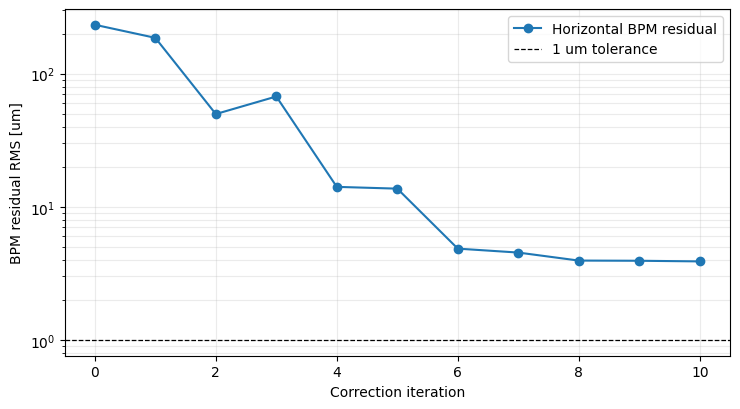

In [35]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.semilogy(
    trim_correction_history['iteration'],
    1e6 * trim_correction_history['x_rms_m'],
    'o-',
    label='Horizontal BPM residual',
)
ax.axhline(1.0, color='black', ls='--', lw=0.9, label='1 um tolerance')
ax.set_xlabel('Correction iteration')
ax.set_ylabel('BPM residual RMS [um]')
ax.grid(alpha=0.25, which='both')
ax.legend()
fig.tight_layout()
plt.show()

In [36]:
twiss_after_dipole_trims = line.twiss(
    eneloss_and_damping=True,
    radiation_analysis=True,
)

/Users/skostogl/Documents/workspace/workspace_2025/python_installation/miniforge3/envs/FCC_xsuite/lib/python3.12/site-packages/xtrack/twiss.py:442: FutureWarning: The `eneloss_and_damping` keyword is deprecated and will be removed in future versions. 
Please use `radiation_analysis` instead, which has the same behavior. This deprecation is part of the interface cleanup in view of the 1.0 release.
  warn('The `eneloss_and_damping` keyword is deprecated and will be removed in future versions. \n'


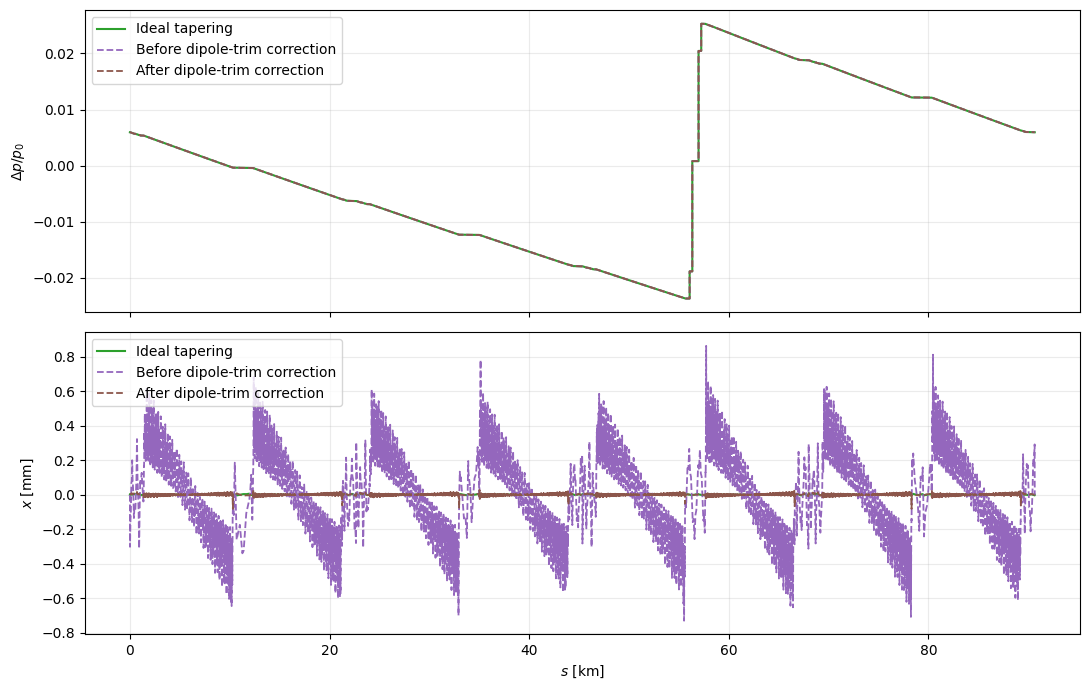

In [37]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

axes[0].plot(
    twiss_ideal.s / 1e3,
    twiss_ideal.delta,
    color="tab:green",
    lw=1.5,
    label="Ideal tapering",
)
axes[0].plot(
    twiss_quad_sext.s / 1e3,
    twiss_quad_sext.delta,
    color="tab:purple",
    ls="--",
    lw=1.3,
    label="Before dipole-trim correction",
)
axes[0].plot(
    twiss_after_dipole_trims.s / 1e3,
    twiss_after_dipole_trims.delta,
    color="tab:brown",
    ls="--",
    lw=1.3,
    label="After dipole-trim correction",
)
axes[0].set_ylabel(r"$\Delta p/p_0$")
axes[0].legend()

axes[1].plot(
    twiss_ideal.s / 1e3,
    twiss_ideal.x * 1e3,
    color="tab:green",
    lw=1.5,
    label="Ideal tapering",
)
axes[1].plot(
    twiss_quad_sext.s / 1e3,
    twiss_quad_sext.x * 1e3,
    color="tab:purple",
    ls="--",
    lw=1.3,
    label="Before dipole-trim correction",
)
axes[1].plot(
    twiss_after_dipole_trims.s / 1e3,
    twiss_after_dipole_trims.x * 1e3,
    color="tab:brown",
    ls="--",
    lw=1.3,
    label="After dipole-trim correction",
)
axes[1].set_xlabel(r"$s$ [km]")
axes[1].set_ylabel(r"$x$ [mm]")
axes[1].legend()

for ax in axes:
    ax.grid(alpha=0.25)

fig.tight_layout()
plt.show()

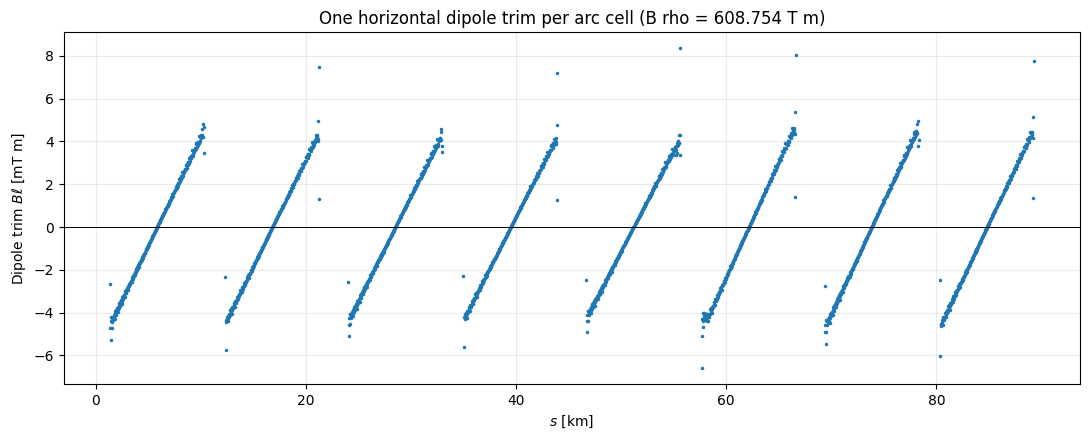

Trims: 2240
RMS kick = 4.30522 urad
Max |kick| = 13.7226 urad
RMS |B*l| = 2.62082 mT m
Max |B*l| = 8.35369 mT m


In [38]:
p0c_GeV = float(line.particle_ref.p0c[0]) * 1e-9
charge_number = abs(float(line.particle_ref.q0))
magnetic_rigidity_Tm = p0c_GeV / (0.299792458 * charge_number)
trim_integrated_field_mTm = trim_kicks_rad * magnetic_rigidity_Tm * 1e3
trim_s_km = trim_layout['s_km'].to_numpy(float)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(trim_s_km, trim_integrated_field_mTm, '.', ms=3)
ax.axhline(0.0, color='black', lw=0.7)
ax.set_xlabel(r'$s$ [km]')
ax.set_ylabel(r'Dipole trim $B\ell$ [mT m]')
ax.grid(alpha=0.25)
ax.set_title(
    f'One horizontal dipole trim per arc cell '
    f'(B rho = {magnetic_rigidity_Tm:.3f} T m)'
)
fig.tight_layout()
plt.show()

print(f'Trims: {len(trim_kicks_rad)}')
print(f'RMS kick = {1e6 * np.sqrt(np.mean(trim_kicks_rad**2)):.6g} urad')
print(f'Max |kick| = {1e6 * np.max(np.abs(trim_kicks_rad)):.6g} urad')
print(f'RMS |B*l| = {np.sqrt(np.mean(trim_integrated_field_mTm**2)):.6g} mT m')
print(f'Max |B*l| = {np.max(np.abs(trim_integrated_field_mTm)):.6g} mT m')

In [39]:
twiss_scenario_2_before_correction = twiss_quad_sext
twiss_scenario_2_after_correction = twiss_after_dipole_trims

In [41]:
beta_beating_x = (
    twiss_scenario_2_after_correction.betx - twiss_ideal.betx
) / twiss_ideal.betx

beta_beating_y = (
    twiss_scenario_2_after_correction.bety - twiss_ideal.bety
) / twiss_ideal.bety


diagnostics = pd.DataFrame({
    "name": np.asarray(twiss_scenario_2_after_correction.name, dtype=str),
    "s_km": np.asarray(twiss_scenario_2_after_correction.s) / 1e3,
    "beta_beating_x": beta_beating_x,
    "beta_beating_y": beta_beating_y,
    "orbit_x_mm": (
        twiss_scenario_2_after_correction.x - twiss_ideal.x
    ) * 1e3,
})


print("Largest horizontal beta beating:")

display(
    diagnostics.iloc[
        np.argsort(np.abs(beta_beating_x))[-15:]
    ].sort_values(
        "beta_beating_x",
        key=np.abs,
        ascending=False,
    )
)


print("Largest vertical beta beating:")

display(
    diagnostics.iloc[
        np.argsort(np.abs(beta_beating_y))[-15:]
    ].sort_values(
        "beta_beating_y",
        key=np.abs,
        ascending=False,
    )
)

Largest horizontal beta beating:


,name,s_km,beta_beating_x,beta_beating_y,orbit_x_mm
9648,mbd.2139,28.927201,0.018764,-0.008150,0.000187
9647,||drift_36::715,28.927051,0.018746,-0.008129,0.000215
9644,hcor_qd1a.275,28.926531,0.018637,-0.008053,0.000312
9645,vcor_qd1a.275,28.926531,0.018637,-0.008053,0.000312
9646,sd1a.129,28.926531,0.018637,-0.008053,0.000312
9643,bpm_qd1a.275,28.926531,0.018637,-0.008053,0.000312
9642,||drift_34::253,28.926431,0.018608,-0.008039,0.000331
9688,||drift_36::722,29.052181,0.018457,0.005351,-0.000201
9689,sd1a.130,29.052331,0.018423,0.005312,-0.000239
11079,||drift_36::950,32.699391,-0.018282,0.012230,0.003548


Largest vertical beta beating:


,name,s_km,beta_beating_x,beta_beating_y,orbit_x_mm
13082,||drift_36::1231,39.611781,0.009057,0.031722,0.000805
13083,qf2a.372,39.611931,0.009025,0.031685,0.000798
13260,mbd.2994,40.063061,0.011014,0.031478,-0.000006
13259,||drift_36::1260,40.062911,0.011001,0.031471,0.000036
13139,||drift_62::307,39.752745,-0.000473,0.030859,-0.000274
13140,mbd.2965,39.752780,-0.000484,0.030856,-0.000268
13202,||drift_62::318,39.922063,0.005161,0.030423,0.000863
13203,mbd.2981,39.922098,0.005170,0.030421,0.000864
13258,qf2a.378,40.060021,0.010873,0.030283,0.000822
13257,||drift_34::455,40.059921,0.010873,0.030208,0.000848


In [42]:
def twiss_scalar(twiss, *candidate_names):
    for name in candidate_names:
        value = getattr(twiss, name, None)
        if value is not None:
            array = np.asarray(value)
            if array.size:
                return float(array.reshape(-1)[0])
    return np.nan

def rms(values):
    values = np.asarray(values, dtype=float)
    return float(np.sqrt(np.nanmean(values**2)))

def max_abs(values):
    return float(np.nanmax(np.abs(np.asarray(values, dtype=float))))

def percent_change(value, reference):
    if not np.isfinite(reference) or reference == 0:
        return np.nan
    return 100.0 * (value/reference - 1.0)

def complete_optics_summary(twiss, reference):
    betx_beating = (twiss.betx-reference.betx)/reference.betx
    bety_beating = (twiss.bety-reference.bety)/reference.bety
    delta_x = twiss.x-reference.x
    delta_y = twiss.y-reference.y
    delta_dx = twiss.dx-reference.dx
    delta_dy = twiss.dy-reference.dy

    emit_x = twiss_scalar(twiss, 'eq_gemitt_x', 'rad_int_eq_gemitt_x')
    emit_y = twiss_scalar(twiss, 'eq_gemitt_y', 'rad_int_eq_gemitt_y')
    emit_x_ref = twiss_scalar(reference, 'eq_gemitt_x', 'rad_int_eq_gemitt_x')
    emit_y_ref = twiss_scalar(reference, 'eq_gemitt_y', 'rad_int_eq_gemitt_y')

    return {
        'Horizontal tune Qx': twiss_scalar(twiss, 'qx'),
        'Vertical tune Qy': twiss_scalar(twiss, 'qy'),
        'Horizontal tune shift': twiss_scalar(twiss, 'qx')-twiss_scalar(reference, 'qx'),
        'Vertical tune shift': twiss_scalar(twiss, 'qy')-twiss_scalar(reference, 'qy'),
        'Horizontal chromaticity Qx_prime': twiss_scalar(twiss, 'dqx'),
        'Vertical chromaticity Qy_prime': twiss_scalar(twiss, 'dqy'),
        'Minimum tune separation |C-|': twiss_scalar(twiss, 'c_minus'),
        'Synchrotron tune Qs': twiss_scalar(twiss, 'qs'),
        'RMS beta-x beating [%]': 100*rms(betx_beating),
        'Maximum beta-x beating [%]': 100*max_abs(betx_beating),
        'RMS beta-y beating [%]': 100*rms(bety_beating),
        'Maximum beta-y beating [%]': 100*max_abs(bety_beating),
        'RMS horizontal-orbit residual [um]': 1e6*rms(delta_x),
        'Maximum horizontal-orbit residual [um]': 1e6*max_abs(delta_x),
        'RMS vertical-orbit residual [um]': 1e6*rms(delta_y),
        'Maximum vertical-orbit residual [um]': 1e6*max_abs(delta_y),
        'RMS horizontal-dispersion residual [mm]': 1e3*rms(delta_dx),
        'Maximum horizontal-dispersion residual [mm]': 1e3*max_abs(delta_dx),
        'RMS vertical-dispersion residual [mm]': 1e3*rms(delta_dy),
        'Maximum vertical-dispersion residual [mm]': 1e3*max_abs(delta_dy),
        'Equilibrium horizontal emittance [nm]': 1e9*emit_x,
        'Horizontal emittance change [%]': percent_change(emit_x, emit_x_ref),
        'Equilibrium vertical emittance [pm]': 1e12*emit_y,
        'Vertical emittance change [%]': percent_change(emit_y, emit_y_ref),
        'Equilibrium longitudinal emittance [um]': 1e6*twiss_scalar(
            twiss, 'eq_gemitt_zeta', 'rad_int_eq_gemitt_zeta'),
        'Equilibrium momentum spread [%]': 100*twiss_scalar(
            twiss, 'eq_sigma_delta', 'rad_int_sigma_delta'),
        'Equilibrium bunch length [mm]': 1e3*twiss_scalar(
            twiss, 'eq_sigma_zeta', 'eq_sigma_z', 'rad_int_sigma_zeta'),
        'Energy loss per turn [GeV]': 1e-9*twiss_scalar(
            twiss, 'eneloss_turn', 'rad_int_energy_loss'),
        'Momentum compaction factor': twiss_scalar(
            twiss, 'momentum_compaction_factor'),
        'Slip factor': twiss_scalar(twiss, 'slip_factor'),
    }

optics_comparison = pd.DataFrame({
    'Ideal tapering': complete_optics_summary(twiss_ideal, twiss_ideal),
    'Scenario 2 before correction': complete_optics_summary(
        twiss_scenario_2_before_correction, twiss_ideal),
    'Scenario 2 after dipole-trim correction': complete_optics_summary(
        twiss_after_dipole_trims, twiss_ideal),
})
pd.set_option('display.max_rows', None)
display(optics_comparison)

/Users/skostogl/Documents/workspace/workspace_2025/python_installation/miniforge3/envs/FCC_xsuite/lib/python3.12/site-packages/xtrack/twiss.py:3761: FutureWarning: `eneloss_turn` is deprecated, use `energy_loss` instead. This deprecation is part of the interface cleanup in view of the 1.0 release.
  warn(object.__getattribute__(self, '_DEPRECATED_FIELDS')[name], FutureWarning)


,Ideal tapering,Scenario 2 before correction,Scenario 2 after dipole-trim correction
Horizontal tune Qx,3.461316e+02,3.461398e+02,3.461289e+02
Vertical tune Qy,2.622813e+02,2.622788e+02,2.622791e+02
Horizontal tune shift,0.000000e+00,8.156060e-03,-2.691208e-03
Vertical tune shift,0.000000e+00,-2.447030e-03,-2.143699e-03
Horizontal chromaticity Qx_prime,4.605618e+00,4.565509e+00,4.606379e+00
Vertical chromaticity Qy_prime,3.873636e+00,3.750051e+00,3.870982e+00
Minimum tune separation |C-|,1.946384e-10,2.728271e-10,2.586610e-10
Synchrotron tune Qs,9.183682e-02,9.179464e-02,9.182862e-02
RMS beta-x beating [%],0.000000e+00,2.725167e+00,8.489810e-01
Maximum beta-x beating [%],0.000000e+00,6.206268e+00,1.876437e+00


In [43]:
# Focused equilibrium-emittance comparison.
emittance_rows = [
    'Equilibrium horizontal emittance [nm]',
    'Horizontal emittance change [%]',
    'Equilibrium vertical emittance [pm]',
    'Vertical emittance change [%]',
    'Equilibrium momentum spread [%]',
    'Equilibrium bunch length [mm]',
]
display(optics_comparison.loc[emittance_rows])

,Ideal tapering,Scenario 2 before correction,Scenario 2 after dipole-trim correction
Equilibrium horizontal emittance [nm],2.189257,2.190525,2.191987
Horizontal emittance change [%],0.000000,0.057915,0.124708
Equilibrium vertical emittance [pm],0.063788,0.063755,0.063923
Vertical emittance change [%],0.000000,-0.051562,0.211541
Equilibrium momentum spread [%],NaN,NaN,NaN
Equilibrium bunch length [mm],NaN,NaN,NaN


# Horizontal optics comparison for every case

The dispersion is compared directly with the ideal lattice. The beta beating is shown as the relative difference from the ideal horizontal beta function.

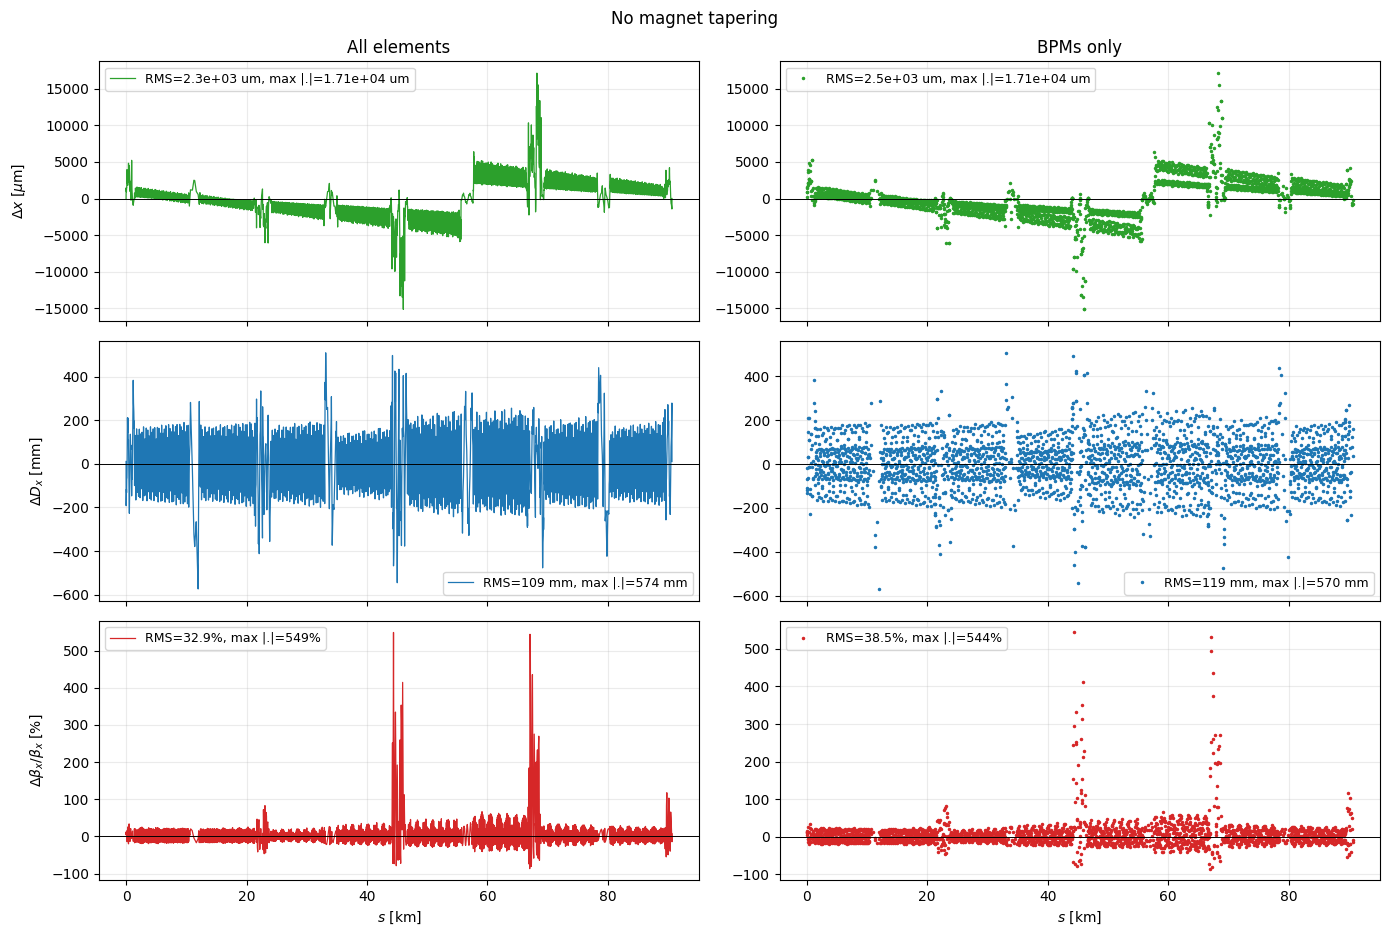

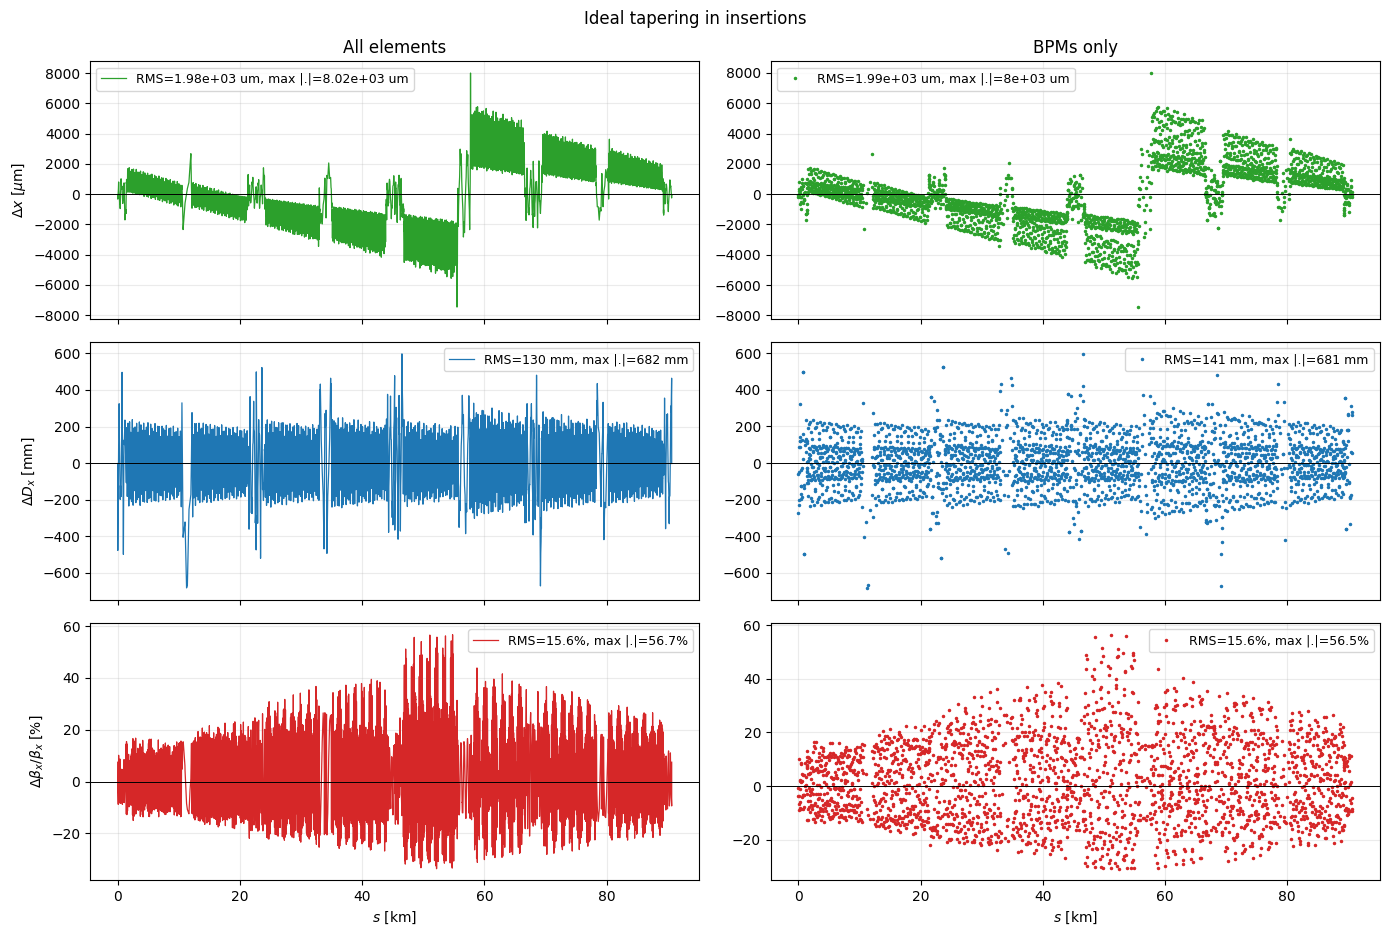

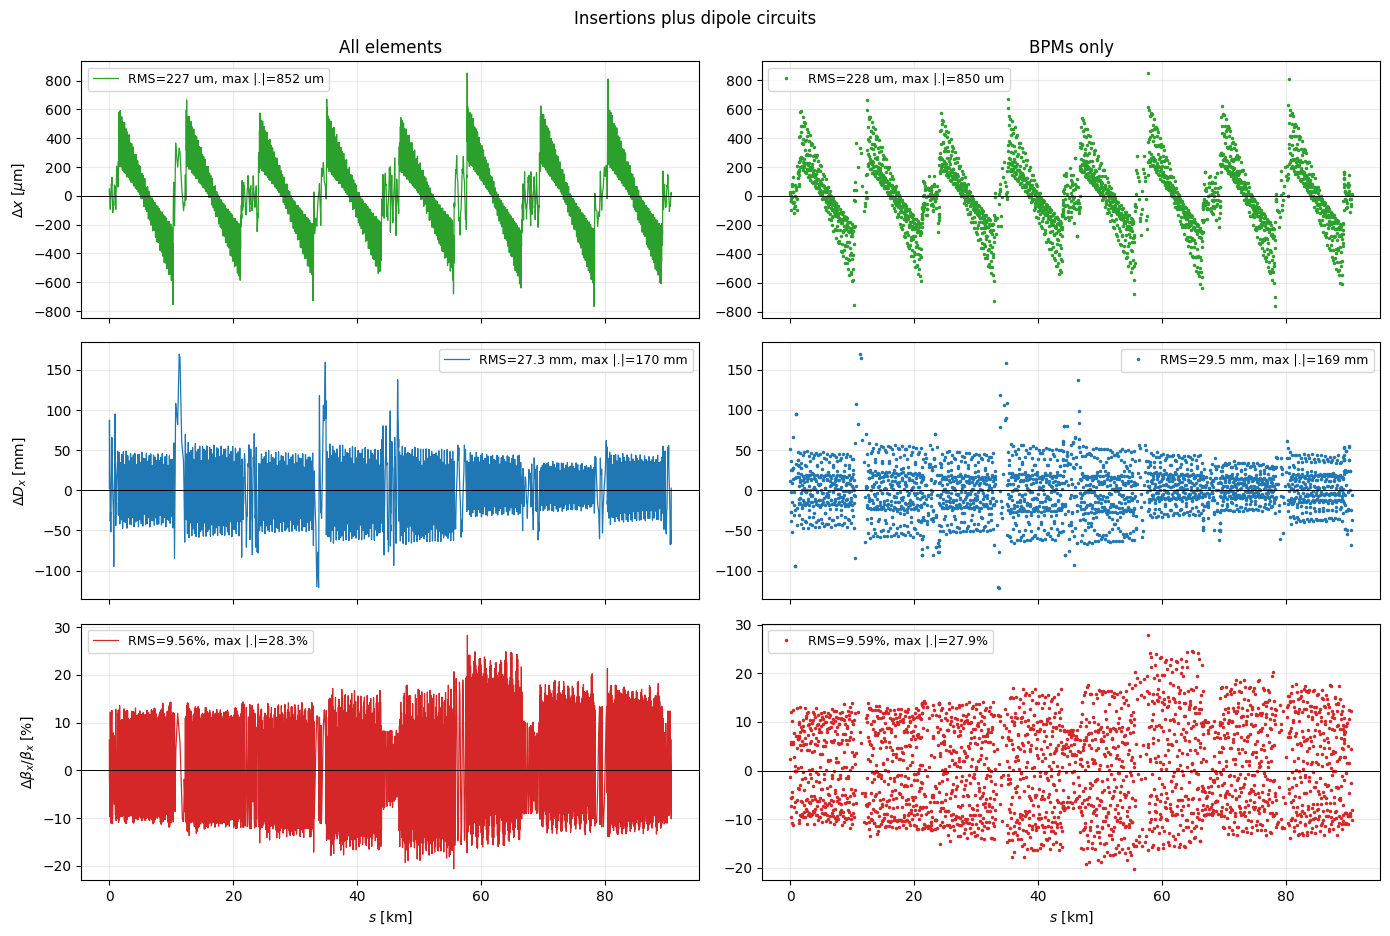

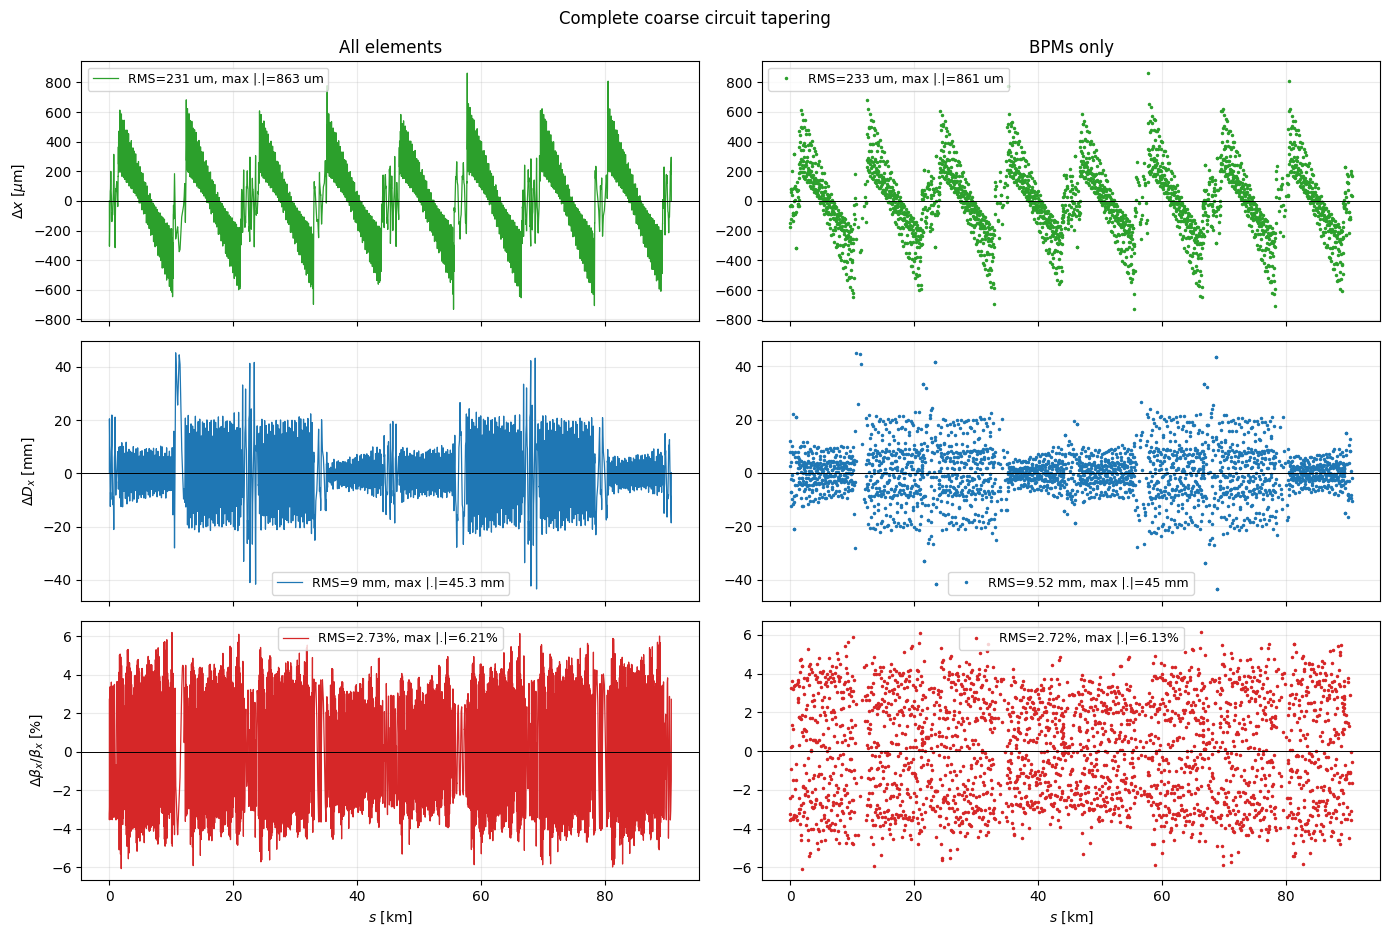

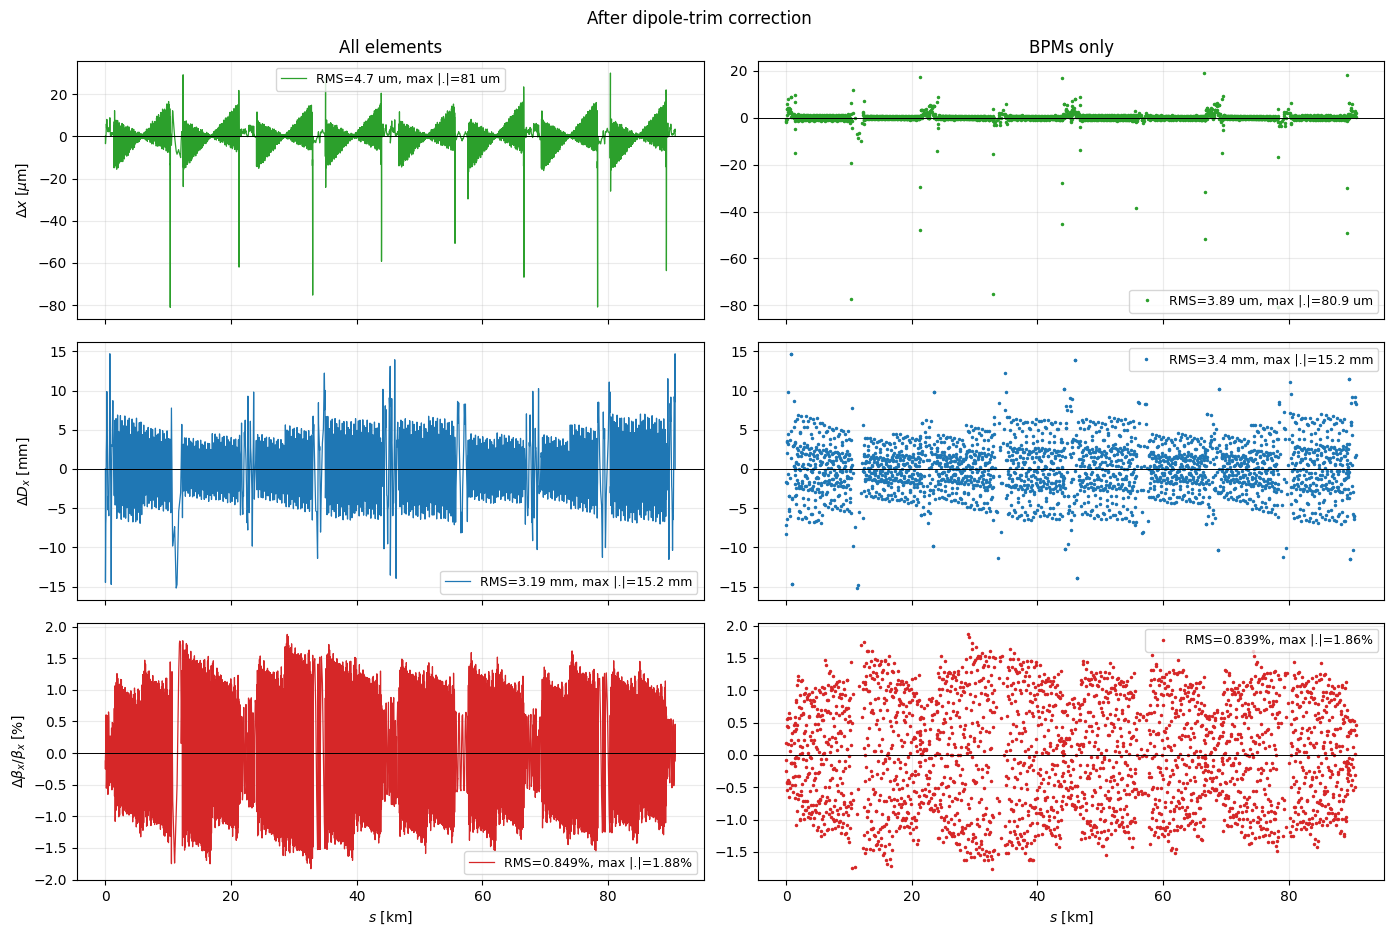

In [44]:
def plot_horizontal_optics_case(twiss_case, reference, label, bpm_names):
    bpm_names = list(np.asarray(bpm_names, dtype=str))

    # All Twiss locations
    s_all_km = np.asarray(reference.s, dtype=float) / 1e3
    delta_orbit_x_all_um = 1e6 * (
        np.asarray(twiss_case.x, dtype=float)
        - np.asarray(reference.x, dtype=float)
    )
    delta_dispersion_all_mm = 1e3 * (
        np.asarray(twiss_case.dx, dtype=float)
        - np.asarray(reference.dx, dtype=float)
    )
    beta_beating_all_percent = 100.0 * (
        np.asarray(twiss_case.betx, dtype=float)
        / np.asarray(reference.betx, dtype=float) - 1.0
    )

    # BPM locations only. Obtain the indices independently from each table.
    reference_bpm_indices = reference.rows.indices[bpm_names]
    case_bpm_indices = twiss_case.rows.indices[bpm_names]
    s_bpm_km = np.asarray(reference.s[reference_bpm_indices], dtype=float) / 1e3
    delta_orbit_x_bpm_um = 1e6 * (
        np.asarray(twiss_case.x[case_bpm_indices], dtype=float)
        - np.asarray(reference.x[reference_bpm_indices], dtype=float)
    )
    delta_dispersion_bpm_mm = 1e3 * (
        np.asarray(twiss_case.dx[case_bpm_indices], dtype=float)
        - np.asarray(reference.dx[reference_bpm_indices], dtype=float)
    )
    beta_beating_bpm_percent = 100.0 * (
        np.asarray(twiss_case.betx[case_bpm_indices], dtype=float)
        / np.asarray(reference.betx[reference_bpm_indices], dtype=float) - 1.0
    )

    def statistics(values):
        values = np.asarray(values, dtype=float)
        return np.sqrt(np.nanmean(values**2)), np.nanmax(np.abs(values))

    orbit_all_rms, orbit_all_max = statistics(delta_orbit_x_all_um)
    orbit_bpm_rms, orbit_bpm_max = statistics(delta_orbit_x_bpm_um)
    dx_all_rms, dx_all_max = statistics(delta_dispersion_all_mm)
    dx_bpm_rms, dx_bpm_max = statistics(delta_dispersion_bpm_mm)
    betx_all_rms, betx_all_max = statistics(beta_beating_all_percent)
    betx_bpm_rms, betx_bpm_max = statistics(beta_beating_bpm_percent)

    fig, axes = plt.subplots(3, 2, figsize=(14, 9.5), sharex='col')
    axes[0, 0].plot(s_all_km, delta_orbit_x_all_um, color='tab:green', lw=0.9,
                    label=f'RMS={orbit_all_rms:.3g} um, max |.|={orbit_all_max:.3g} um')
    axes[0, 1].plot(s_bpm_km, delta_orbit_x_bpm_um, '.', color='tab:green', ms=3,
                    label=f'RMS={orbit_bpm_rms:.3g} um, max |.|={orbit_bpm_max:.3g} um')
    axes[1, 0].plot(s_all_km, delta_dispersion_all_mm, color='tab:blue', lw=0.9,
                    label=f'RMS={dx_all_rms:.3g} mm, max |.|={dx_all_max:.3g} mm')
    axes[1, 1].plot(s_bpm_km, delta_dispersion_bpm_mm, '.', color='tab:blue', ms=3,
                    label=f'RMS={dx_bpm_rms:.3g} mm, max |.|={dx_bpm_max:.3g} mm')
    axes[2, 0].plot(s_all_km, beta_beating_all_percent, color='tab:red', lw=0.9,
                    label=f'RMS={betx_all_rms:.3g}%, max |.|={betx_all_max:.3g}%')
    axes[2, 1].plot(s_bpm_km, beta_beating_bpm_percent, '.', color='tab:red', ms=3,
                    label=f'RMS={betx_bpm_rms:.3g}%, max |.|={betx_bpm_max:.3g}%')

    axes[0, 0].set_title('All elements')
    axes[0, 1].set_title('BPMs only')
    axes[0, 0].set_ylabel(r'$\Delta x$ [$\mu$m]')
    axes[1, 0].set_ylabel(r'$\Delta D_x$ [mm]')
    axes[2, 0].set_ylabel(r'$\Delta\beta_x/\beta_x$ [%]')
    axes[2, 0].set_xlabel(r'$s$ [km]')
    axes[2, 1].set_xlabel(r'$s$ [km]')

    for ax in axes.flat:
        ax.axhline(0.0, color='black', lw=0.7)
        ax.grid(alpha=0.25)
        ax.legend(fontsize=9)

    fig.suptitle(label)
    fig.tight_layout()
    plt.show()

case_twiss_tables = {
    'No magnet tapering': tw_no_taper,
    'Ideal tapering in insertions': twiss_insertion_taper,
    'Insertions plus dipole circuits': twiss_dipole,
    'Complete coarse circuit tapering': twiss_quad_sext,
    'After dipole-trim correction': twiss_after_dipole_trims,
}

for case_label, case_twiss in case_twiss_tables.items():
    plot_horizontal_optics_case(case_twiss, twiss_ideal, case_label, monitor_names)

# Dipole-trim distribution

In [66]:
# The trim integrated-field distribution was calculated above.
trim_strength_summary = pd.DataFrame({
    'dipole': trim_dipole_names,
    's_km': trim_s_km,
    'kick_urad': 1e6 * trim_kicks_rad,
    'length_m': trim_layout['length_m'].to_numpy(float),
    'integrated_field_mTm': trim_integrated_field_mTm,
})
trim_strength_summary["field mT"] = trim_strength_summary["integrated_field_mTm"] / trim_strength_summary["length_m"]
display(trim_strength_summary.head(12))

,dipole,s_km,kick_urad,length_m,integrated_field_mTm,field mT
0,mbd.0,1.363667,-4.339646,9.613334,-2.641779,-0.274804
1,mbd.3,1.394737,-7.784597,9.613334,-4.738908,-0.492952
2,mbd.6,1.428962,-7.220974,9.613334,-4.395800,-0.457261
3,mbd.9,1.461062,-8.649195,9.613334,-5.265236,-0.547701
4,mbd.12,1.495687,-6.899162,9.613334,-4.199896,-0.436882
5,mbd.15,1.526757,-7.727062,9.613334,-4.703884,-0.489308
6,mbd.18,1.559257,-6.947970,9.613334,-4.229608,-0.439973
7,mbd.21,1.590947,-7.265047,9.613334,-4.422630,-0.460052
8,mbd.24,1.623447,-6.917612,9.613334,-4.211127,-0.438051
9,mbd.27,1.655137,-7.124375,9.613334,-4.336995,-0.451144
